## SETUP

In [1]:
import sys
import matplotlib.pyplot as plt
import cartopy.crs as ccrs                   # import projections
import cartopy.feature as cf                 # import features
import numpy as np
import copy
import matplotlib.patheffects as path_effects
import collections
import networkx as nx
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import pylab as pl
from matplotlib import cm
from matplotlib.colors import ListedColormap

### CMAP PARA CHUVA ############################
top = cm.get_cmap('Greens', 12)
bottom = cm.get_cmap('Oranges_r', 12)
newcolors = np.vstack((bottom(np.linspace(0, 1, 12)),
                       top(np.linspace(0, 1, 12))))
cmpchuva = ListedColormap(newcolors, name='OrangeGreen')
################################################

def PlotSeries(fig, series, color_pos='r',color_neg='b',label_pos=None,label_neg=None,Title=None,start = 0,bottom=False,No_frame=True):
    # FUNCAO QUE PLOTA SERIES
    
    #### Linhas constantes de +1 e -1 #
    xx=list(range(0, len(series)))
    x=copy.deepcopy(xx)
    for i in range(len(xx)):
        x[i]=1+(0.5+xx[i])/12
    y=[1]*len(x)
    yy=[-1]*len(x)
    ###################################
    
    plt.fill_between(x, series,
                     where=(series > 0),
                     alpha=0.50, color=color_pos, interpolate=True, label=label_pos)
    plt.fill_between(x, series,
                     where=(series < 0),
                     alpha=0.50, color=color_neg, interpolate=True, label=label_neg)
    
    #fig.title.set_text(Title)
    fig.set_ylabel(Title,fontweight ='bold')
    plt.tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        bottom=bottom,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        labelbottom=bottom) # labels along the bottom edge are off
    if bottom:
        fig.set_xlabel('sim year',fontweight ='bold')
    plt.plot(x[start:len(x)],y[start:len(x)],linestyle=":",color=color_pos,alpha=0.5)
    plt.plot(x[start:len(x)],yy[start:len(x)],linestyle=":",color=color_neg,alpha=0.5)
    
    if No_frame:
        for spine in fig.spines.values():
            spine.set_visible(False)
            
def PlotSeries_c(fig, clusters,Title=None,start = 0,No_frame=True,min_persistence=0):
    
    #### Linhas constantes de +1 e -1 #
    xx=list(range(0, len(clusters)))
    x=copy.deepcopy(xx)
    for i in range(len(xx)):
        x[i]=1+(0.5+xx[i])/12
    y=[1]*len(x)
    yy=[-1]*len(x)
    ###################################
    
    #fig.title.set_text(Title)
    plt.tick_params(
        axis='x',          # changes apply to the x-axis
        which='both',      # both major and minor ticks are affected
        #bottom=False,      # ticks along the bottom edge are off
        top=False,         # ticks along the top edge are off
        #labelbottom=False) # labels along the bottom edge are off
    )
    
    persistent_clusters = []
    i = 0
    while i < len(clusters):
        cluster_id = clusters[i]
        inicio = i
        while i < len(clusters) and clusters[i] == cluster_id:
            i += 1
        duracao = i - inicio
        # A verificação de min_size já é feita aqui
        if duracao >= min_persistence:
            persistent_clusters.append(cluster_id)       

    plt.plot(x, clusters, "")
    antigo =-1
    i=0
    persistent = persistent_clusters[i]
    for xs, cs in zip(x, clusters):
        if antigo != cs:
            if cs == persistent:
                plt.text(xs, cs+0.5 , str(int(cs)), color="k", fontsize=12, weight='bold')
                i+=1
                if i < len(persistent_clusters):
                    persistent = persistent_clusters[i]
            else:
                plt.text(xs, cs+0.5 , str(int(cs)), color="k", fontsize=10)
            antigo = cs
        else:
            antigo = cs
    
    fig.set_ylabel('cluster',fontweight ='bold')
    fig.set_xlabel('sim year',fontweight ='bold')
    if No_frame:
        for spine in fig.spines.values():
            spine.set_visible(False)
            
def progressbar(it, prefix="", size=40, file=sys.stdout):
    count = len(it)
    def show(j):
        x = int(size*j/count)
        space=int((size-18)/2)
        a='#'*space
        mensagem = a + ' VAI CORINTHIANS! ' + a
        file.write("%s[%s%s] %i/%i\r" % (prefix, mensagem[0:x], "."*(size-x), j, count)) #"#"*x
        file.flush()        
    show(0)
    for i, item in enumerate(it):
        yield item
        show(i+1)
    file.write("\n")
    file.flush()

def smooth(x,window_len=1,window='hanning'):
    """smooth the data using a window with requested size.
    
    This method is based on the convolution of a scaled window with the signal.
    The signal is prepared by introducing reflected copies of the signal 
    (with the window size) in both ends so that transient parts are minimized
    in the begining and end part of the output signal.
    
    input:
        x: the input signal 
        window_len: the dimension of the smoothing window; should be an odd integer
        window: the type of window from 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'
            flat window will produce a moving average smoothing.

    output:
        the smoothed signal
        
    example:

    t=linspace(-2,2,0.1)
    x=sin(t)+randn(len(t))*0.1
    y=smooth(x)
    
    see also: 
    
    numpy.hanning, numpy.hamming, numpy.bartlett, numpy.blackman, numpy.convolve
    scipy.signal.lfilter
 
    TODO: the window parameter could be the window itself if an array instead of a string
    NOTE: length(output) != length(input), to correct this: return y[(window_len/2-1):-(window_len/2)] instead of just y.
    """

    if x.ndim != 1:
        raise ValueError("smooth only accepts 1 dimension arrays.")

    if x.size < window_len:
        raise ValueError("Input vector needs to be bigger than window size.")


    if window_len<3:
        return x


    if not window in ['flat', 'hanning', 'hamming', 'bartlett', 'blackman']:
        raise ValueError("Window is on of 'flat', 'hanning', 'hamming', 'bartlett', 'blackman'")


    s=np.r_[x[window_len-1:0:-1],x,x[-2:-window_len-1:-1]]
    #print(len(s))
    if window == 'flat': #moving average
        w=np.ones(window_len,'d')
    else:
        w=eval('np.'+window+'(window_len)')

    y=np.convolve(w/w.sum(),s,mode='valid')
    return y[(window_len//2-1):-(window_len//2)]

def MOD_anomalia(vetor,lat,lon):
    # calcula a anomalia dos diferentes modelos dentro do vetor
    
    anomalia=copy.deepcopy(vetor)
        
    if len(vetor.shape)==4:
        for i in range(len(vetor)):

            # Climatologia 
            temp=vetor[i] # shape: (time,lon,lat)
            end=len(temp)
            mediatemp=copy.deepcopy(temp[0:12,:,:])
            for j in range(12):
                zz=copy.deepcopy(temp[j:end:12,:,:])
                mediatemp[j,:,:]=np.nanmean(zz[:,:,:], axis=0) # vetor com médias/climatologia

            #CALCULO DO VETOR ANOMALIA
            for t in range(12):
                anomalia[i,t:end:12,:,:]=temp[t:end:12,:,:]-mediatemp[t,:,:]
    else:
        # Climatologia 
        temp=vetor # shape: (time,lon,lat)
        end=len(temp)
        mediatemp=copy.deepcopy(temp[0:12,:,:])
        for j in range(12):
            zz=copy.deepcopy(temp[j:end:12,:,:])
            mediatemp[j,:,:]=np.nanmean(zz[:,:,:], axis=0) # vetor com médias/climatologia

        #CALCULO DO VETOR ANOMALIA
        for t in range(12):
            anomalia[t:end:12,:,:]=temp[t:end:12,:,:]-mediatemp[t,:,:]
        

    return anomalia


def clusteriza2d(proj1, proj2, limite1=1, limite2=1):
    # proj1 e proj2 são listas dos índices de todos os modelos (shape: n_modelos,time)
    # clusteriza sistema bi-dimensional em 9 clusters
    # a partir dos limites estabelecidos para as séries de índices proj1, proj2
    
    cluster = []
    phase = np.zeros((len(proj1), len(proj1[0]), 2))  # apenas 2 dimensões
    m = -1
    
    for nino, amm in zip(proj1, proj2):
        m += 1
        # normalização
        nino, amm = nino / np.std(nino), amm / np.std(amm)
        
        cluster_series = np.zeros(nino.shape[0])
        
        for t in range(len(nino)):
            # NINO positivo
            if nino[t] > limite1:
                phase[m, t, 0] = 1
                if amm[t] > limite2:       # AMM positivo
                    phase[m, t, 1] = 1
                    cluster_series[t] = 2
                elif amm[t] < -limite2:    # AMM negativo
                    phase[m, t, 1] = -1
                    cluster_series[t] = 4
                else:                      # AMM neutro
                    phase[m, t, 1] = 0
                    cluster_series[t] = 3
            
            # NINO negativo
            elif nino[t] < -limite1:
                phase[m, t, 0] = -1
                if amm[t] > limite2:       # AMM positivo
                    phase[m, t, 1] = 1
                    cluster_series[t] = 8
                elif amm[t] < -limite2:    # AMM negativo
                    phase[m, t, 1] = -1
                    cluster_series[t] = 6
                else:                      # AMM neutro
                    phase[m, t, 1] = 0
                    cluster_series[t] = 7
            
            # NINO neutro
            else:
                phase[m, t, 0] = 0
                if amm[t] > limite2:       # AMM positivo
                    phase[m, t, 1] = 1
                    cluster_series[t] = 1
                elif amm[t] < -limite2:    # AMM negativo
                    phase[m, t, 1] = -1
                    cluster_series[t] = 5
                else:                      # AMM neutro
                    phase[m, t, 1] = 0
                    cluster_series[t] = 0
        
        cluster.append(cluster_series)
    
    return cluster, phase
# CLUSTERIZA DE ACORDO COM COMPONENTES do PCA
def clusteriza3d(proj1,proj2,proj3,limite1=1,limite2=1,limite=1):
    # proj1,2 e 3 sao listas dos indices de todos os modelos (shape: n_modelos,time)
    # clusteriza sistema tri-dimensional em 27 clusters
    # a partir do limite estabelecido para as series de indices proj1,proj2,proj3
    
    cluster = []
    phase = np.zeros((len(proj1),len(proj1[0]),3)) 
    m=-1
    for nino,amm,sasd in zip(proj1,proj2,proj3):
        m+=1
        nino,amm,sasd = nino/np.std(nino),amm/np.std(amm),sasd/np.std(sasd)
        cluster_series = np.zeros(nino.shape[0])
        for t in range(len(nino)):
            if nino[t] > limite1: # NINO pos
                phase[m,t,0]=1
                if amm[t] > limite2: # AMM pos
                    phase[m,t,1]=1
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=26
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=1
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=2
                elif amm[t] < -limite2: # AMM neg
                    phase[m,t,1]=-1
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=3
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=4
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=5
                else: # AMM neutro
                    phase[m,t,1]=0
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=6
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=7
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=8

            elif nino[t] < -limite1: # Nino neg
                phase[m,t,0]=-1
                if amm[t] > limite2: # AMM pos
                    phase[m,t,1]=1
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=9
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=10
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=11
                elif amm[t] < -limite2: # AMM neg
                    phase[m,t,1]=-1
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=12
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=13
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=14
                else: # AMM neutro
                    phase[m,t,1]=0
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=15
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=16
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=17

            else: # Nino neutro
                phase[m,t,0]=0
                if amm[t] > limite2: # AMM pos
                    phase[m,t,1]=1
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=18
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=19
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=20
                elif amm[t] < -limite2: # AMM neg
                    phase[m,t,1]=-1
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=21
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=22
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=23
                else: # AMM neutro
                    phase[m,t,1]=0
                    if sasd[t] > limite: # SASD pos
                        phase[m,t,2]=1
                        cluster_series[t]=24
                    elif sasd[t] < -limite: # SASD neg
                        phase[m,t,2]=-1
                        cluster_series[t]=25
                    else: # SASD neutro
                        phase[m,t,2]=0
                        cluster_series[t]=0
        cluster.append(cluster_series)                
    return cluster, phase

# Cria vetor com Cluster Patterns:
def Make_Cluster_Pattern(cluster,vetor,modo = 'sst',n_clusters=27):
    # vetor é o vetor com a serie temporal da variavel
    # a.k.a. Vtosa ou Vppta #
    Cluster_pattern = []
    for c in range(n_clusters): # estados possiveis, sao 27
        #mascara de clusters
        masc = ( cluster == c )
        try:
            Cluster_pattern.append(np.nanmean(vetor[masc],axis=0))
        except:
            print('Cluster number', c,' is not present in this simulation')
            Cluster_pattern.append(np.zeros(vetor[0].shape))
        
    return Cluster_pattern

# Calcula Entropias
def Entropia(Clusterseries):
    #calcula entropia de uma lista de dicionários (conjunto de vetores)
    
    #cria vetor que guarda entropia de cada serie temporal do Clusterseries
    Entropia = np.zeros(len(Clusterseries))
    
    # CONTA VALORES TOTAIS DE APARIÇÕES DE CADA ESTADO DO SISTEMA
    for m in range(len(Clusterseries)):
        dic={}
        size=len(Clusterseries[m])
        
        for val in Clusterseries[m]:
            if val in dic:
                dic[val]+=1
            else:
                dic[val]=1
                    
        Entropiadaserie=0    
        # Calcula Entropia da serie temporal
        for Val in dic.values():
            # a probabilidade é o numero de vezes que aquele cluster apareceu dividido pelo numero total de passos temporais
            prob=Val/size
            Entropiadaserie=Entropiadaserie+prob*np.log(prob)

        # Guarda a entropia num vetor
        Entropia[m]=Entropiadaserie

    return - Entropia


def Plot_sequence_with_maps(cluster_sst, Cluster_pattern, color='red', zoom=0.4, with_maps=True):
    # 1. Processamento: Identificar clusters e suas DURAÇÕES (size)
    sequencia = []
    duracoes = []
    
    if len(cluster_sst) > 0:
        c_atual = cluster_sst[0]
        count = 0
        for i in range(len(cluster_sst)):
            if cluster_sst[i] == c_atual:
                count += 1
            else:
                sequencia.append(c_atual)
                duracoes.append(count)
                c_atual = cluster_sst[i]
                count = 1
        # Adiciona o último grupo
        sequencia.append(c_atual)
        duracoes.append(count)

    # 2. Calcular posições X baseadas no tempo acumulado (ponto médio da duração)
    # Ex: se o primeiro dura 10, o centro dele é em 5. O próximo começa em 10.
    x_positions = []
    current_x = 0
    for d in duracoes:
        x_positions.append(current_x + d/2)
        current_x += d

    # 3. Configuração do Gráfico
    # O figsize agora é proporcional ao tempo total da série
    tempo_total = sum(duracoes)
    plt.figure(figsize=(max(15, tempo_total * 0.2), 5), dpi=80)
    ax = plt.gca()
    
    norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)
    y_fixed = 0
    
    # Linha horizontal representando a linha do tempo real
    ax.plot([0, tempo_total], [y_fixed, y_fixed], color='gray', alpha=0.3, zorder=1)

    for i, cluster_id in enumerate(sequencia):
        x = x_positions[i]
        size = duracoes[i] # Tempo de permanência
        
        if with_maps:
            # No modo mapas, o zoom pode ser levemente influenciado pelo size se desejar, 
            # mas aqui manteremos fixo para não distorcer o padrão 2D.
            pattern = Cluster_pattern[int(cluster_id)]
            img = OffsetImage(pattern, zoom=zoom, cmap='RdBu_r', norm=norm, origin='lower')
            ab = AnnotationBbox(img, (x, y_fixed), frameon=True, pad=0.1)
            ax.add_artist(ab)
            
            txt = ax.text(x, y_fixed + 0.6, str(int(cluster_id)), fontsize=12, 
                          fontweight='bold', ha='center', va='bottom')
        else:
            # --- MODO BOLINHAS (Tamanho proporcional à duração) ---
            circle_color = 'red' if color == 'red' else 'blue'
            # Ajuste o multiplicador (500) para o tamanho desejado
            area_size = 500 + (size * 100) 
            
            ax.scatter(x, y_fixed, s=area_size, color=circle_color, 
                       edgecolors='black', alpha=0.7, zorder=2)
            
            txt = ax.text(x, y_fixed, str(int(cluster_id)), fontsize=14, 
                          fontweight='bold', ha='center', va='center', color='black')

        txt.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()])

    # Ajustes finais
    ax.set_xlim(0, tempo_total)
    ax.set_ylim(-1, 1.5)
    # Mostrar os anos no eixo X para dar contexto temporal
    ax.set_axis_on()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax.set_xlabel("Sim Year (Tempo)", fontweight='bold')
    
    plt.title("Evolução Temporal dos Clusters (Espaçamento por Duração)", fontsize=15)
    plt.tight_layout()
    plt.show()
    
def Plot_sequence_n_blocks(cluster_sst, Cluster_pattern, n_blocks=3, min_persistence=0,min_size=0, zoom=0.6, with_maps=True, land_mask=None,color ='red'):
    Gs_full = Create_Graf(cluster_sst)
    
    # 1. Filter nodes based on size attribute
    # We create a list of nodes that meet the minimum size requirement
    node_attr = nx.get_node_attributes(Gs_full, 'size')
    nodes_to_keep = [n for n, size in node_attr.items() if size >= min_size]
    
    # 2. Create a subgraph containing only those nodes
    #Gs = Gs_full.subgraph(nodes_to_keep).copy()
    Gs, error_message = build_consistent_graph(cluster_sst, min_persistence, min_size, node_attr)
    
    degrees = dict(Gs.degree())
    deg_values = np.array(list(degrees.values()))

    deg_norm = mcolors.Normalize(vmin=deg_values.min(),vmax=deg_values.max())
    
    cmap = plt.cm.Reds
    cmap_maps='RdBu_r'
    if color == 'blue':
        cmap=plt.cm.Blues
        cmap_maps = cmpchuva

    blocos_estaveis = []
    i = 0
    while i < len(cluster_sst):
        cluster_id, inicio = cluster_sst[i], i
        while i < len(cluster_sst) and cluster_sst[i] == cluster_id:
            i += 1
        duracao = i - inicio
        if duracao >= min_persistence:
            if cluster_id in Gs.nodes:
                blocos_estaveis.append({'id': cluster_id, 'start': inicio, 'dur': duracao})
    if not blocos_estaveis:
        print(f"Nenhum padrão estável (>= {min_persistence}m) encontrado.")
        return

    # 2. Dividir os blocos em N grupos (linhas)
    n_total = len(blocos_estaveis)
    n_per_block = int(np.ceil(n_total / n_blocks))
    linhas = [blocos_estaveis[i:i + n_per_block] for i in range(0, n_total, n_per_block)]
    # REMOVIDO: linhas = linhas[:n_blocks]
    # Agora todas as linhas geradas serão plotadas.

    norm = mcolors.Normalize(vmin=-0.5, vmax=0.5)
    
    for idx, linha in enumerate(linhas):
        if not linha:
            continue
        
        t_inicio_total = linha[0]['start']
        t_fim_total = linha[-1]['start'] + linha[-1]['dur']
        duracao_total_plot = t_fim_total - t_inicio_total

        # Tamanho fixo da figura (15x4) - aumentei a largura para dar mais espaço
        plt.figure(figsize=(13, 3), dpi=90)
        ax = plt.gca()
        
        last_right_edge = -np.inf
        min_map_width_norm = 0.05 
        
        prev_circle_pos = None
        y_pos_circle = 0.75 

        for bloco in linha:
            x_center_real = bloco['start'] + (bloco['dur'] / 2)
            x_center_norm = (x_center_real - t_inicio_total) / duracao_total_plot
            current_left_edge = x_center_norm - min_map_width_norm
            
            if current_left_edge < last_right_edge:
                x_center_norm += (last_right_edge - current_left_edge) + 0.005 
            
            last_right_edge = x_center_norm + min_map_width_norm
            x_center = t_inicio_total + x_center_norm * duracao_total_plot
            
            cid = int(bloco['id'])
            
            if with_maps:
                # 1. Desenha o Mapa
                pattern = Cluster_pattern[cid]
                img = OffsetImage(pattern, zoom=zoom, cmap=cmap_maps, norm=norm, origin='lower')
                ab = AnnotationBbox(img, (x_center, 0), frameon=True, pad=0.1)
                ax.add_artist(ab)
                
                # 2. Desenha a SETA conectando ao círculo anterior
                #if prev_circle_pos is not None:
                #    ax.annotate('', xy=(x_center, y_pos_circle), xytext=(prev_circle_pos, y_pos_circle),
                #                arrowprops=dict(arrowstyle='->', color='black', lw=0.5, shrinkA=15, shrinkB=15))
                
                prev_circle_pos = x_center

                # 3. Desenha o Círculo Vermelho
                ax.scatter(x_center, y_pos_circle, s=550,c=[degrees[cid]],norm=deg_norm,
                           cmap=cmap, edgecolors='black', zorder=4)
                
                # 4. Texto do ID (Branco)
                txt = ax.text(x_center, y_pos_circle, str(cid), fontsize=10, fontweight='bold', 
                        color='black', ha='center', va='center', zorder=5) # Alterado de 'black' para 'white'
                
                # 5. Duração
                ax.text(x_center, y_pos_circle + 0.22, f"{bloco['dur']}m", 
                        fontsize=8, ha='center', va='bottom', fontweight='bold', alpha=0.7)
                
            else:
                # ... (modo sem mapas)
                area = 500 + (bloco['dur'] * 10)
                ax.scatter(x_center, 0, s=area, c='red', edgecolors='black', zorder=2, alpha=0.8, linewidths=1.5)
                txt = ax.text(x_center, 0, str(cid), color='white', ha='center', va='center', fontweight='bold', fontsize=12)

            # Efeito de contorno para o texto
            txt.set_path_effects([path_effects.Stroke(linewidth=2, foreground='white' if with_maps and txt.get_color() == 'white' else 'white' if with_maps else 'black'), path_effects.Normal()])


        # Configurações de Eixo
        # Ajuste o xlim para usar o 'last_right_edge' normalizado para garantir que o último mapa caiba
        right_limit = t_inicio_total + last_right_edge * duracao_total_plot + 10 # Garante espaço extra no final
        # Define os limites visuais (mantendo o respiro de 10 unidades)
        ax.set_xlim(t_inicio_total - 10, right_limit)
        ax.set_ylim(-0.8, 1.6)
        
        # 1. Definir as posições ONDE os ticks (tracinhos) vão aparecer (no eixo esticado)
        # Precisamos definir quantos pontos queremos para true_ticks, digamos 5 também para simplificar
        num_ticks = 5 
        true_ticks_positions = np.linspace(t_inicio_total - 10, right_limit, num_ticks)
        
        # 2. Definir os RÓTULOS que você quer mostrar nesses locais (seus valores de dados puros)
        tick_labels = np.linspace(t_inicio_total, t_fim_total, num_ticks)
        
        # Aplica as posições e os rótulos
        ax.set_xticks(true_ticks_positions)
        # Converte para inteiros para melhor visualização
        ax.set_xticklabels([int(t) for t in tick_labels], fontsize=9) 
        
        # Configurações visuais remanescentes
        ax.set_axis_on()
        ax.set_xlabel(f"Mês da Série Temporal (Linha {idx+1})", fontweight='bold', fontsize=10)
        ax.get_yaxis().set_visible(False)
        for s in ['top', 'right', 'left']:
            ax.spines[s].set_visible(False)
        ax.spines['bottom'].set_linewidth(0.8)

        plt.title(f"Bloco {idx+1} de {len(linhas)} - Sequência de Meses {t_inicio_total} a {t_fim_total}", fontsize=11, pad=15)
        plt.tight_layout()
        plt.show()
        
def Create_Graf(cluster_sst):
    
    Ccyclesst=[]
    sizesst={}
    c_atual=-1
    
    for t in range(len(cluster_sst)):
        c=int(cluster_sst[t])
        if (c in sizesst):
            sizesst[c] += 1
        else:
            sizesst[c] = 1
        if c != c_atual:
            c_atual=c
            Ccyclesst.append(c)

    ## CONTA NUMERO DE VEZES QUE UM CLUSTER EVOLUI PARA OUTRO (CONTA IDA E VOLTA COMO UMA COISA SÓ)
    ## MEDE A LIGACAO ENTRE OS CLUSTERS
    pesoligs={}
    pesos={}
    for i in range(len(Ccyclesst)-1): # calcula total de vezes que um modelo passou para outro
        if Ccyclesst[i] in pesos:     # ou seja, ele reflete a porcentagem de vezes que um cluster passou para outro
            pesos[Ccyclesst[i]] +=1
        else:
            pesos[Ccyclesst[i]] = 1

    for i in range(1,len(Ccyclesst)):
        if str(Ccyclesst[i-1])+str(Ccyclesst[i]) in pesoligs:
            pesoligs[str(Ccyclesst[i-1])+str(Ccyclesst[i])] += 1/pesos[Ccyclesst[i-1]]
        else:
            pesoligs[str(Ccyclesst[i-1])+str(Ccyclesst[i])] = 1/pesos[Ccyclesst[i-1]]

    #position=[(3,0.5),(.5,0),(2.5,0),(2.5,1.5),(0,0.5),(0.5,1.5),(2,0.5),(1.5,0),(1.5,1.5)]
    Gs = nx.DiGraph()
    for c in pesos.keys():
        Gs.add_node(c) # ,pos=position[c]) # posição pre-definida
    dic={}
    for i in range(1,len(Ccyclesst)):
        A=Ccyclesst[i-1]
        B=Ccyclesst[i]
        if str(A)+str(B) in dic:
            a=0
        else:
            pes="{:.2f}".format(pesoligs[str(A)+str(B)])
            Gs.add_edge(A,B,weight = pes)
            dic[str(A)+str(B)]=1

    for i in list(Gs.nodes()):
        try:
            Gs.nodes[i]['size'] = sizesst[i]
        except:
            Gs.nodes[i]['size']=0
    
    return Gs
            
# Função auxiliar para construir o grafo consistente com a sequência filtrada
def build_consistent_graph(cluster_sst, min_persistence, min_size, node_attr):
    bridged_sst = []
    i = 0
    while i < len(cluster_sst):
        cluster_id = cluster_sst[i]
        inicio = i
        while i < len(cluster_sst) and cluster_sst[i] == cluster_id:
            i += 1
        duracao = i - inicio
        # A verificação de min_size já é feita aqui
        if duracao >= min_persistence and cluster_id in node_attr and node_attr[cluster_id] >= min_size:
            bridged_sst.extend([cluster_id] * duracao)
            
    if not bridged_sst:
        return None, "Nenhum padrão estável ou nó de tamanho mínimo encontrado na série."

    Gs = nx.DiGraph()
    Gs.add_nodes_from(set(bridged_sst)) 

    for j in range(len(bridged_sst) - 1):
        u, v = bridged_sst[j], bridged_sst[j+1]
        if Gs.has_edge(u, v):
            Gs[u][v]['weight'] += 1
        else:
            Gs.add_edge(u, v, weight=1)
            
    # Adiciona atributos de tamanho e remove self-loops
    for node_id in list(Gs.nodes):
         if node_id in node_attr:
            Gs.nodes[node_id]['size'] = node_attr[node_id]
    
    Gs.remove_edges_from(nx.selfloop_edges(Gs))
    
    if len(Gs.nodes) == 0:
        return None, "Grafo vazio após remoção de self-loops."
        
    return Gs, None

def Plot_Graf(cluster_sst, color='red', min_persistence=0, min_size=0):
    
    # 1. Preparação dos dados e construção do grafo
    Gs_full = Create_Graf(cluster_sst) 
    node_attr = nx.get_node_attributes(Gs_full, 'size')

    Gs, error_message = build_consistent_graph(cluster_sst, min_persistence, min_size, node_attr)
    
    if Gs is None:
        print(error_message)
        return   
    
    # Define os parâmetros de plotagem uma vez
    node_edge_color = 'red' if color != 'blue' else 'blue'# Cor da borda vermelha
    graph_edge_color = '#606060'
    edge_thickness = 0.5
    arrow_size_val = 15
    cmap = plt.cm.Reds if color != 'blue' else plt.cm.Blues
    
    # --- Início do Plot ---
    for seed in [1,2,3,4,5]: # Use sua lista de seeds aqui
        
        plt.figure(figsize=(10, 5), dpi=80)
    
        node_color = [Gs.degree(v) for v in Gs]
        current_sizes = nx.get_node_attributes(Gs, 'size')
        node_size = [50*6 + 20 * current_sizes[v] for v in Gs]        
        edge_width = [Gs[u][v]['weight'] for u, v in Gs.edges()]
    
        pos = nx.spring_layout(Gs, iterations=30, seed=seed) 
        
        if len(pos) > 0:
            first_node_key = list(pos.keys())[0] # Corrigido para pegar o primeiro elemento
            center_offset = pos[first_node_key]
            for k in pos:
                pos[k] = pos[k] - center_offset
        
        plt.subplot(1,2,1)

        # Desenha Labels com Path Effects
        for node, (x, y) in pos.items():
            label_text = str(int(node)) if isinstance(node, float) else str(node) 
            
            label = plt.text(x, y, label_text,
                             fontsize=20, ha='center', va='center', color='black', zorder=10)
            label.set_path_effects([
                path_effects.Stroke(linewidth=3, foreground='white'), path_effects.Normal()
            ])

        # Desenha o Grafo
        nx.draw_networkx(Gs, 
                         node_size=node_size, node_color=node_color, alpha=1.0, 
                         with_labels=False, width=edge_thickness, pos=pos,
                         edge_color=graph_edge_color, cmap=cmap, arrowsize=arrow_size_val, arrows=True)
    
        ax = plt.gca()
        
        # CORREÇÃO DO ERRO AQUI: Itere sobre a coleção para aplicar as configurações
        if ax.collections:
            for collection in ax.collections:
                collection.set_edgecolor(node_edge_color) # Aplica a cor da borda vermelha
                collection.set_linewidth(1.5) # Aumenta um pouco a espessura da borda para destacar
            
        plt.axis('off')
        plt.tight_layout()
        plt.show()

# GMD SCRIPTS

### Climate simulations and Observation data in 3D PC phasespace

In [2]:
# Observations
# len(vector) = time
proj1_obs_s = np.load('proj1_s_obs_final.npy')
proj2_obs_s = np.load('proj2_s_obs_final.npy')
proj3_obs_s = np.load('proj3_s_obs_final.npy')
proj1_obs_p = np.load('proj1_p_obs_final.npy')
proj2_obs_p = np.load('proj2_p_obs_final.npy')
proj3_obs_p = np.load('proj3_p_obs_final.npy')
AMM_obs  = np.load('AMM_obs_final.npy')
NINO_obs = np.load('NINO_obs_final.npy')
SASD_obs = np.load('SASD_obs_final.npy')
# MODELS
# FUll 100 year simulations
# vector.shape = (sim_number,sim_time)
proj1_s = np.load('proj1_s_final.npy')
proj2_s = np.load('proj2_s_final.npy')
proj3_s = np.load('proj3_s_final.npy')
proj1_p = np.load('proj1_p_final.npy')
proj2_p = np.load('proj2_p_final.npy')
proj3_p = np.load('proj3_p_final.npy')
AMM  = np.load('AMM_final.npy')
NINO = np.load('NINO_final.npy')
SASD = np.load('SASD_final.npy')


In [3]:
# Pre_calculated Entropies using trreshold interval from 0.2 to 0.9 STD
# Models
Entropys_PCA_mod = np.load('Entropys_PCA_detrend_final.npy') # 'Entropys_PCA_detrend_final.npy'
Entropyp_PCA_mod = np.load('Entropyp_PCA_detrend_final.npy') # 'Entropyp_PCA_detrend_final.npy'
Entropys_INDEX_mod   = np.load('Entropys_INDEX_detrend_final.npy') # 'Entropys_INDEX_detrend_final.npy'
Entropys_PCA_mod_short = np.load('Entropys_PCA_detrend_short_final.npy') # 'Entropys_PCA_detrend_final.npy'
Entropyp_PCA_mod_short = np.load('Entropyp_PCA_detrend_short_final.npy') # 'Entropyp_PCA_detrend_final.npy'
Entropys_INDEX_mod_short   = np.load('Entropys_INDEX_detrend_short_final.npy') # 'Entropys_INDEX_detrend_final.npy'
# Observations
Entropys_PCA_obs = np.load('Entropyp_PCA_obs_mod_final.npy')
Entropyp_PCA_obs = np.load('Entropyp_PCA_obs_mod_final.npy')
Entropyp_INDEX_obs = np.load('Entropys_INDEX_obs_final.npy')

### Entropy maximum tresholds

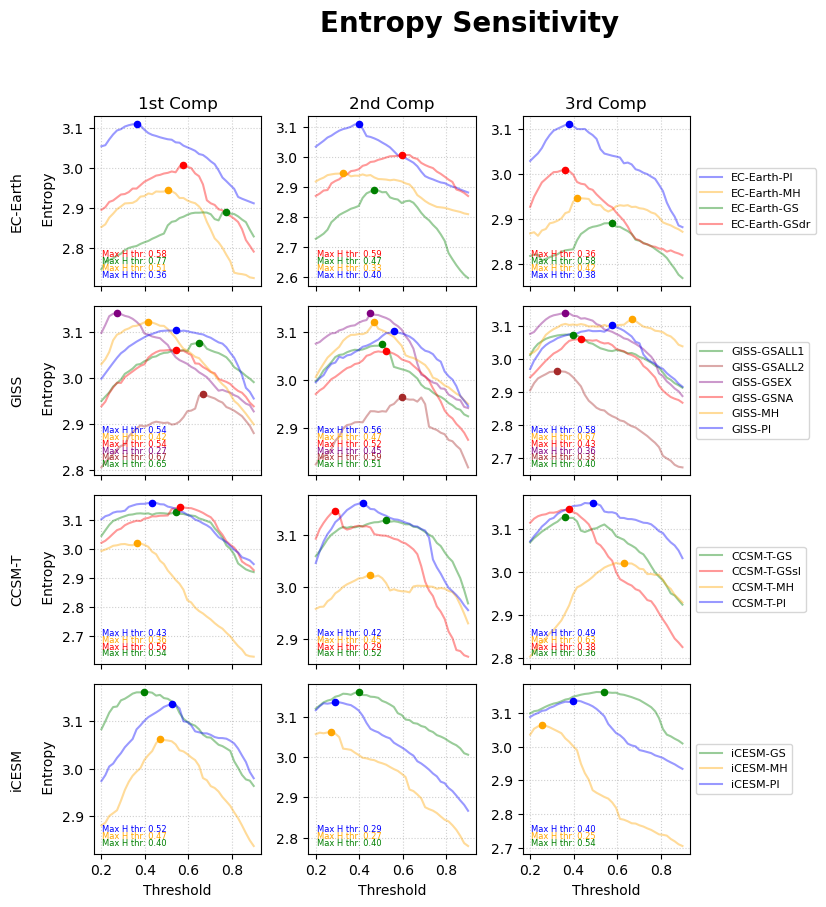

In [4]:
model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CCSM-T','CCSM-T','CCSM-T','CCSM-T']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']

Entropy = Entropys_PCA_mod
limites = np.linspace(0.2, 0.9, num=40)
titulos_grupos = ['EC-Earth', 'GISS', 'CCSM-T', 'iCESM']

fig, axs = plt.subplots(4, 3, figsize=(9.5, 9.5), sharex=True)
fig.suptitle('Entropy Sensitivity', fontsize=20, fontweight='bold')

text_offsets = { (r, c): 0.05 for r in range(4) for c in range(3) }

cores_map = {
    'PI': 'blue',
    'MH': 'orange',     # MH_PMIP
    'GS': 'green',    # MH_GS
    'GSdr': 'red',  # MH_GSrd (ajustado para 'GSdr' conforme seu vetor)
    'GSALL1': 'green',
    'GSALL2': 'brown',
    'GSEX': 'purple',
    'GSNA': 'red',
    'GSsl': 'red'
}

for n, Value in enumerate(Entropy):
    Model_index = np.argmax(Value)
    i_idx, j_idx, k_idx = np.unravel_index(Model_index, Value.shape)
    
    nome = model[n]
    if   nome[:8] == 'EC-Earth': row_idx = 0
    elif nome[:4] == 'GISS':     row_idx = 1
    elif nome[:6] == 'CCSM-T':   row_idx = 2
    elif nome[:5] == 'iCESM':    row_idx = 3
    else: continue

    cor_cenario = cores_map.get(cenario[n], 'gray')
    
    label_curva = f"{nome}-{cenario[n]}"
    max_vals = [limites[i_idx], limites[j_idx], limites[k_idx]]
    curvas = [Value[:, j_idx, k_idx], Value[i_idx, :, k_idx], Value[i_idx, j_idx, :]]

    for col_idx, dados in enumerate(curvas):
        ax = axs[row_idx, col_idx]
        
        line, = ax.plot(limites, dados, label=label_curva, color=cor_cenario, alpha=0.4, linewidth=1.5)
        # Maximum #
        ax.scatter(max_vals[col_idx], dados.max(), color=cor_cenario, s=20, zorder=3)
        
        # Text threshold max
        y_pos = text_offsets[(row_idx, col_idx)]
        ax.text(0.05, y_pos, f"Max H thr: {max_vals[col_idx]:.2f}", 
                transform=ax.transAxes, 
                color=cor_cenario, 
                fontsize=6,)
        
        text_offsets[(row_idx, col_idx)] += 0.04

for r in range(4):
    for c, comp in enumerate(['1st', '2nd', '3rd']):
        ax = axs[r, c]
        ax.grid(True, linestyle=':', alpha=0.6)
        if r == 0: ax.set_title(comp + " Comp", fontsize=12)
        if c == 0: ax.set_ylabel(f"{titulos_grupos[r]}\n\n Entropy")
        if r == 3: ax.set_xlabel('Threshold')
    
    axs[r, 2].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)

plt.tight_layout(rect=[0, 0.03, 0.88, 0.95])
plt.show()

## Trajectories in Phase Space

In [7]:
# THE ECEarth_PI simulation maps of Tropical and South Altantic.
ECE_PI = np.load('ECE_PI.npy')
m=0

### Using fixed 0.5 Std treshold

In [8]:

var = ECE_PI
# Clusters
cluster_ppt_PCA = clusteriza3d(proj1_p,proj2_p,proj3_p,limite=0.5)[0]
cluster_sst_PCA = clusteriza3d(proj1_s,proj2_s,proj3_s,limite=0.5)[0]

Cluster_patterns_PCA = Make_Cluster_Pattern(cluster_sst_PCA[m],var,modo = 'sst',n_clusters=27)

/tmp/ipykernel_16706/3887710335.py:417: RuntimeWarning: Mean of empty slice
  Cluster_pattern.append(np.nanmean(vetor[masc],axis=0))


### Using Maximum Entropy Treshold

In [9]:
# Clusters
limites = np.linspace(0.2, 0.9, num=40)

Model_index         = np.argmax(Entropys_PCA_mod[m])
i_idx, j_idx, k_idx = np.unravel_index(Model_index, Entropys_PCA_mod[m].shape)
cluster_sst_PCA     = clusteriza3d(proj1_s,proj2_s,proj3_s,limite1=limites[i_idx],limite2=limites[j_idx],limite=limites[k_idx])[0]

Cluster_patterns_PCA = Make_Cluster_Pattern(cluster_sst_PCA[m],var,modo = 'sst',n_clusters=27)

/tmp/ipykernel_16706/3887710335.py:417: RuntimeWarning: Mean of empty slice
  Cluster_pattern.append(np.nanmean(vetor[masc],axis=0))


## Print Indexes, Trajectories and System States

<Figure size 640x480 with 0 Axes>

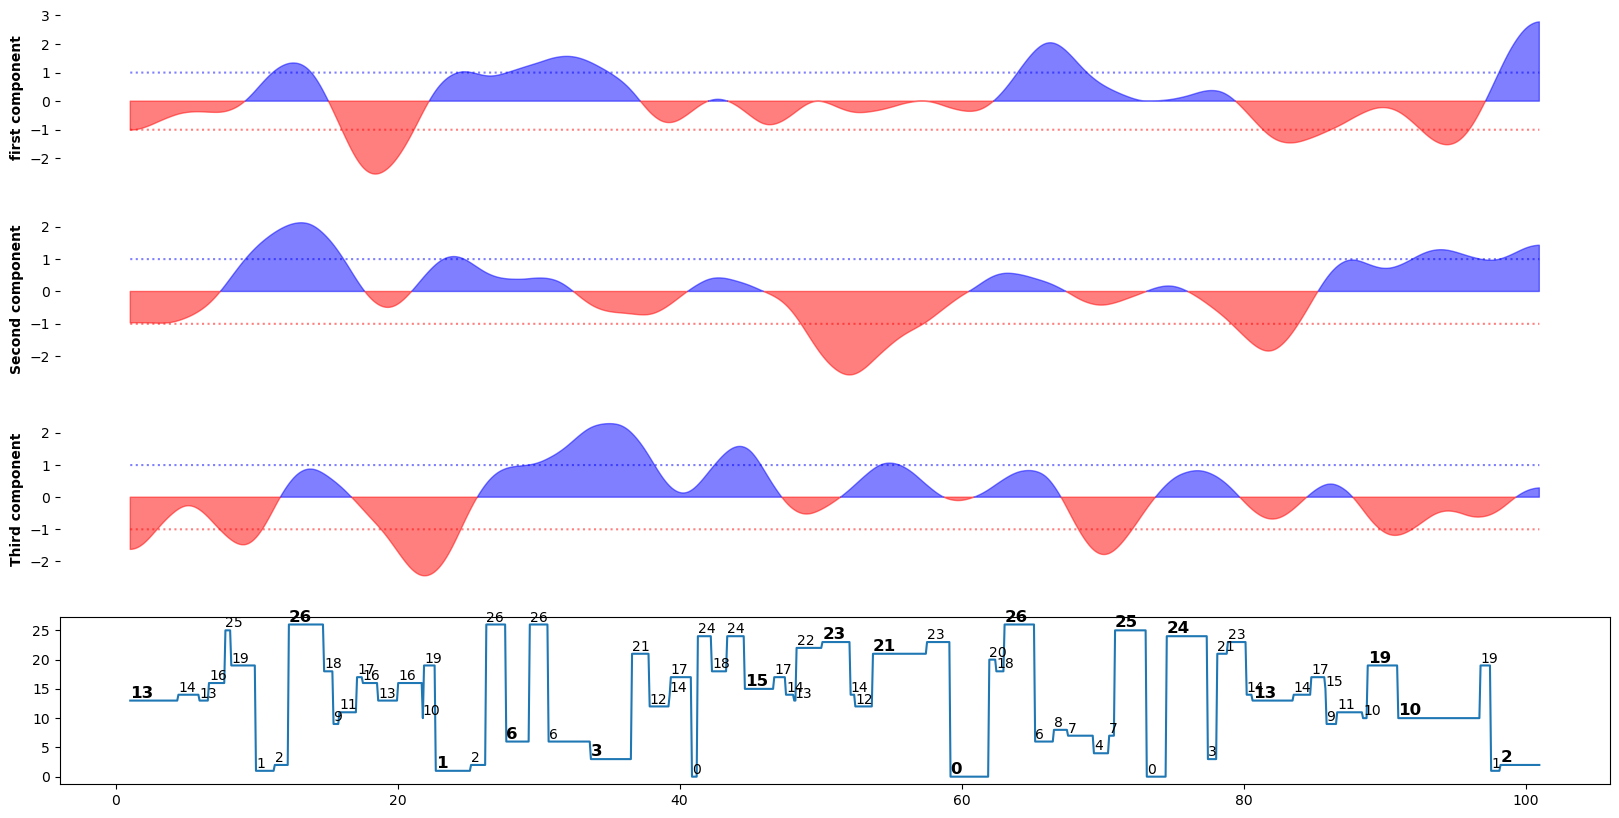

In [11]:
# 1st PC
plt.figure()
fig = plt.figure(figsize=(20,5*2))#

a= fig.add_subplot(4, 1,1)
PlotSeries(a, proj1_s[m],color_pos='blue',color_neg='red',
           label_pos='positive',label_neg='negative',
           Title='first component',start = 0)

# 2nd PC
a= fig.add_subplot(4, 1,2)
PlotSeries(a, proj2_s[m],color_pos='blue',color_neg='red',
           label_pos='positive',label_neg='negative',
           Title='Second component',start = 0)

# 3rd PC
a= fig.add_subplot(4, 1,3)
PlotSeries(a, proj3_s[m],color_pos='blue',color_neg='red',
           label_pos='positive',label_neg='negative',
           Title='Third component',start = 0)

# Clusters
a= fig.add_subplot(4, 1,4)
PlotSeries_c(ax,cluster_sst_PCA[m],  Title='clusters',min_persistence=24)

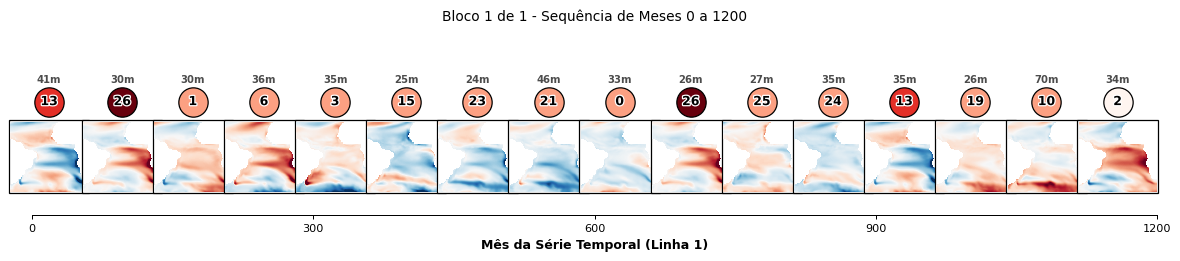

In [12]:
Plot_sequence_n_blocks(cluster_sst_PCA[m], Cluster_patterns_PCA, n_blocks=1,
                       min_persistence=24,min_size=0, zoom=0.7,
                       with_maps=True,land_mask=None,color='red')

### GRAPHS

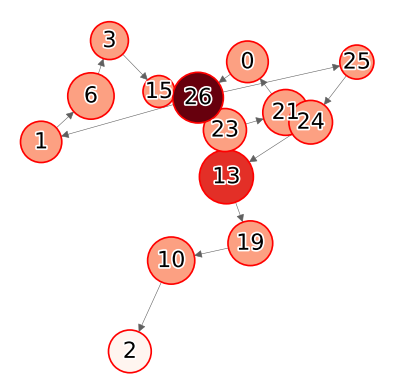

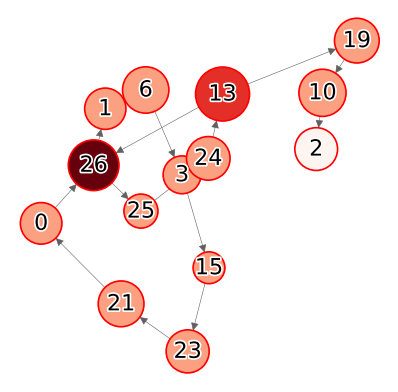

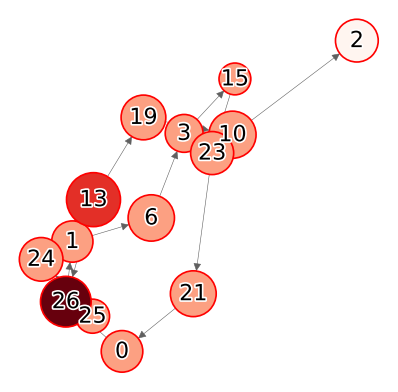

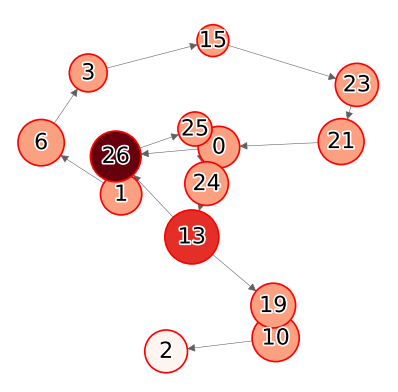

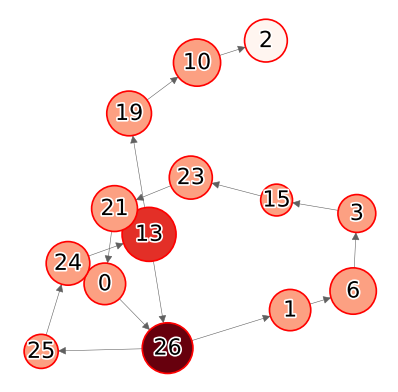

In [14]:
Plot_Graf(cluster_sst_PCA[m],color='red',min_persistence=24,min_size=0)

## SHANNON ENTROPY

In [ ]:
## Compute SST Entropy using proj1_s,proj2_s,proj3_s
## and Precipitation Entropies using proj1_p,proj2_p,proj3_p
limites = np.linspace(0.2, 0.9, num=40)
model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CCSM-T','CCSM-T','CCSM-T','CCSM-T']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']

Entropys_PCAseries = np.zeros( (len(model),len(limites),len(limites),len(limites)) )
Entropyp_PCAseries = np.zeros( (len(model),len(limites),len(limites),len(limites)) )
i=-1
for limite1 in progressbar(limites):
    i+=1
    j=-1
    for limite2 in limites:
        j+=1
        k=-1
        for limite3 in limites:
            k+=1
            # lista de limites contendo lista de modelos
            c,p = clusteriza3d(proj1_s,proj2_s,proj3_s,limite1=limite1,limite2=limite2,limite=limite3)
            S   = Entropia( c )
            Se = Edge_Entropy( p,variances )
            c,p = clusteriza3d(proj1_p,proj2_p,proj3_p,limite1=limite1,limite2=limite2,limite=limite3)
            P   = Entropia( c )
            Pe = Edge_Entropy( p,variancep )
            Entropys_series[:,i,j,k] = S
            Entropyp_series[:,i,j,k] = P

In [15]:
# Pre-calculated Entropies
Entropys_PCA_mod = np.load('Entropys_PCA_detrend_final.npy')
Entropyp_PCA_mod = np.load('Entropyp_PCA_detrend_final.npy')
Entropys_INDEX   = np.load('Entropys_INDEX_detrend_final.npy')
Entropys_PCA_obs = np.load('Entropyp_PCA_obs_mod_final.npy')
Entropyp_PCA_obs = np.load('Entropyp_PCA_obs_mod_final.npy')
Entropyp_INDEX_obs = np.load('Entropys_INDEX_obs_final.npy')


In [16]:

### TABELA COM RESULTADOS #####################
from prettytable import PrettyTable
#
K=1 # constante de Boltzman
model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CESM-Toronto','CESM-Toronto','CESM-Toronto','CESM-Toronto']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']

#vetores para entropia das simulacoes
entropias_PCA_mod=np.zeros(len(cenario))
entropiap_PCA_mod=np.zeros(len(cenario))
entropias_INDEX=np.zeros(len(cenario))
# Selects the maximum Entropy from the possible tested thresholds #

for n in range(len(model)):
    entropias_PCA_mod[n]=np.max(Entropys_PCA_mod[n])*K # /len(Clusterseries[n]) # por mes
    entropiap_PCA_mod[n]=np.max(Entropyp_PCA_mod[n])*K # /len(Clusterseries[n]) # por mes
    entropias_INDEX[n]  =np.max(Entropys_INDEX[n])*K # /len(Clusterseries[n]) # por mes
K=1
entropias_PCA_obs=np.max(Entropys_PCA_obs)*K # /len(Clusterseries[n]) # por mes
entropiap_PCA_obs=np.max(Entropyp_PCA_obs)*K # /len(Clusterseries[n]) # por mes
entropias_INDEX_obs=np.max(Entropyp_INDEX_obs)*K # /len(Clusterseries[n]) # por mes

print('ENTROPIAS DO DOMINIO INTEGRADO (Tropical South Atlantic)')
## Prints table
table = PrettyTable()
x = PrettyTable(['Modelo','Cenário', 'H_PCA sst', 'H_PCA prep', 'H_SST_MODES'])
x.padding_width = 1
for n in range(len(cenario)):
    x.add_row([model[n],cenario[n], str( round(entropias_PCA_mod[n],2)), str( round(entropiap_PCA_mod[n],2) ), str( round(entropias_INDEX[n],2)) ] )
x.add_row(['OBS','1980-2015', str( round(entropias_PCA_obs,2)), str( round(entropiap_PCA_obs,2) ), str( round(entropias_INDEX_obs,2) ) ] )

print(x)
###############################################

ENTROPIAS DO DOMINIO INTEGRADO (Tropical South Atlantic)
+--------------+-----------+-----------+------------+-------------+
|    Modelo    |  Cenário  | H_PCA sst | H_PCA prep | H_SST_MODES |
+--------------+-----------+-----------+------------+-------------+
|   EC-Earth   |     PI    |    3.11   |    3.03    |     2.59    |
|   EC-Earth   |     MH    |    2.95   |    3.03    |     2.75    |
|   EC-Earth   |     GS    |    2.89   |    3.04    |     3.07    |
|   EC-Earth   |    GSdr   |    3.01   |    3.05    |     3.1     |
|     GISS     |   GSALL1  |    3.08   |    3.17    |     2.95    |
|     GISS     |   GSALL2  |    2.96   |    3.06    |     2.93    |
|     GISS     |    GSEX   |    3.14   |    3.16    |     3.13    |
|     GISS     |    GSNA   |    3.06   |    3.14    |     3.08    |
|     GISS     |     MH    |    3.12   |    3.05    |     3.11    |
|     GISS     |     PI    |    3.1    |    3.17    |     2.94    |
|    iCESM     |     GS    |    3.16   |    2.92    |     3

## ENTROPY UNCERTAINTY ( BOOTSTRAP ) - EC-Earth Pi experiment

In [68]:
# Calculates a short Bootstrap
B = 100  # SIZE OF BOOTSTRAP SAMPLES
N = 420  # MONTHS in EACH SAMPLE

limites = np.linspace(0.1, 1, num=20)
model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CCSM-T','CCSM-T','CCSM-T','CCSM-T']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']

Entropys_PCA_bootstrap = np.zeros(B)

In [71]:
m = 0 # EC-Earth_PI_experiment
for b in progressbar(range(B)):
    
    indices_amostra = np.random.choice(N, size=N, replace=True)
    
    Entropys_boot = np.zeros( (len(limites),len(limites),len(limites)) )
    
    P1s = proj1_s[m,indices_amostra]
    P2s = proj2_s[m,indices_amostra]
    P3s = proj3_s[m,indices_amostra]
    
    i=-1
    for limite1 in limites:
        i+=1
        j=-1
        for limite2 in limites:
            j+=1
            k=-1
            for limite3 in limites:
                k+=1#
                # lista de limites contendo lista de modelos
                cs,_ = clusteriza3d([P1s],[P2s],[P3s],limite1=limite1,limite2=limite2,limite=limite3)
                S  = Entropia( cs )
                Entropys_boot[i,j,k]       = S
                
    Es = np.max(np.max(np.max(Entropys_boot,axis=0),axis=0),axis=0)
    
    Entropys_PCA_bootstrap[b]   = Es

IOStream.flush timed out


IOStream.flush timed out


IOStream.flush timed out


IOStream.flush timed out


IOStream.flush timed out


[########### VAI CORINTHIANS! ###########] 100/100


In [76]:
intervalo_confianca_s = np.percentile(Entropy_bootstrap, [2.5, 97.5], axis=0)
STD = -(intervalo_confianca_s[0]-intervalo_confianca_s[1])
    
print('EC-Earth PI experiment Entropy maximum and Uncertainty: ', round(np.max(Entropys_PCA_mod[0]),2),'+/-', STD)

EC-Earth PI experiment Entropy maximum and Uncertainty:  3.11 +/- 0.0967883925880555


In [17]:
# Pre_calculated Bootstraps of all simulations:
# ENTROPIES
Entropys_PCA_mod = np.load('Entropys_PCA_detrend_final.npy') # 'Entropys_PCA_detrend_final.npy'
Entropyp_PCA_mod = np.load('Entropyp_PCA_detrend_final.npy') # 'Entropyp_PCA_detrend_final.npy'
Entropys_INDEX   = np.load('Entropys_INDEX_detrend_final.npy') # 'Entropys_INDEX_detrend_final.npy'
Entropys_PCA_mod_short = np.load('Entropys_PCA_detrend_short_final.npy') # 'Entropys_PCA_detrend_final.npy'
Entropyp_PCA_mod_short = np.load('Entropyp_PCA_detrend_short_final.npy') # 'Entropyp_PCA_detrend_final.npy'
Entropys_INDEX_short   = np.load('Entropys_INDEX_detrend_short_final.npy') # 'Entropys_INDEX_detrend_final.npy'
Entropys_PCA_obs = np.load('Entropys_PCA_obs_mod_final.npy')
Entropyp_PCA_obs = np.load('Entropyp_PCA_obs_mod_final.npy')
Entropyp_INDEX_obs = np.load('Entropys_INDEX_obs_final.npy')

# UNCERTAINTIES (Bootstraps)
Entropys_PCA_bootstrap   = np.load('Entropys_PCA_bootstrap_final.npy')
Entropyp_PCA_bootstrap   = np.load('Entropyp_PCA_bootstrap_final.npy')
Entropys_INDEX_bootstrap = np.load('Entropys_INDEX_bootstrap_final.npy')
Entropys_PCA_short_bootstrap   = np.load('Entropys_PCA_short_bootstrap_final.npy')
Entropyp_PCA_short_bootstrap   = np.load('Entropyp_PCA_short_bootstrap_final.npy')
Entropys_INDEX_short_bootstrap = np.load('Entropys_INDEX_short_bootstrap_final.npy')
Entropys_PCAobs_bootstrap   = np.load('Entropys_PCA_obs_bootstrap_final.npy')
Entropyp_PCAobs_bootstrap   = np.load('Entropyp_PCA_obs_bootstrap_final.npy')
Entropys_INDEXobs_bootstrap = np.load('Entropys_INDEX_obs_bootstrap_final.npy')


In [18]:
Entropy_series    = Entropys_PCA_mod  
Entropy_bootstrap = Entropys_PCA_bootstrap

# Confidence Interval (95%)
STDs=[]
for n,modelo in enumerate(model):
    intervalo_confianca_s = np.percentile(Entropy_bootstrap[n], [2.5, 97.5], axis=0)
    # Resultados
    STDs.append(-(intervalo_confianca_s[0]-intervalo_confianca_s[1]))
    
limites = np.linspace(0.2, 0.9, num=40)
lista_sst = []
entropias=[]

print('Entropy Maximum and Uncertainty:')
for entropia,modelo,cen,STD in zip(Entropy_series,model,cenario,STDs):
    arg = np.unravel_index(np.argmax(entropia),entropia.shape)
    entropias.append(round(np.max(entropia),2))
    print(modelo,cen,'entropy:', round(np.max(entropia),2),'+/-',round(STD,2),'. thresholds:', round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3))
print('Mean: ',np.mean(entropias))

Entropy Maximum and Uncertainty:
EC-Earth PI entropy: 3.11 +/- 0.05 . thresholds: 0.362 0.397 0.379
EC-Earth MH entropy: 2.95 +/- 0.06 . thresholds: 0.505 0.326 0.415
EC-Earth GS entropy: 2.89 +/- 0.06 . thresholds: 0.774 0.469 0.577
EC-Earth GSdr entropy: 3.01 +/- 0.08 . thresholds: 0.577 0.595 0.362
GISS GSALL1 entropy: 3.08 +/- 0.04 . thresholds: 0.649 0.505 0.397
GISS GSALL2 entropy: 2.96 +/- 0.07 . thresholds: 0.667 0.595 0.326
GISS GSEX entropy: 3.14 +/- 0.04 . thresholds: 0.272 0.451 0.362
GISS GSNA entropy: 3.06 +/- 0.06 . thresholds: 0.541 0.523 0.433
GISS MH entropy: 3.12 +/- 0.05 . thresholds: 0.415 0.469 0.667
GISS PI entropy: 3.1 +/- 0.05 . thresholds: 0.541 0.559 0.577
iCESM GS entropy: 3.16 +/- 0.05 . thresholds: 0.397 0.397 0.541
iCESM MH entropy: 3.06 +/- 0.06 . thresholds: 0.469 0.272 0.254
iCESM PI entropy: 3.14 +/- 0.05 . thresholds: 0.523 0.29 0.397
CESM-Toronto GS entropy: 3.13 +/- 0.05 . thresholds: 0.541 0.523 0.362
CESM-Toronto GSsl entropy: 3.15 +/- 0.05 . thr

#### Entropy Plots with Uncertainties (bootstrap analysis)

In [19]:
K=1 # constant
model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CESM-Toronto','CESM-Toronto','CESM-Toronto','CESM-Toronto']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']
entropias=np.zeros(len(cenario))
entropiap=np.zeros(len(cenario))
STDs=np.zeros(len(cenario))
STDp=np.zeros(len(cenario))


# Selects the maximum Entropy from the possible tested thresholds #
Entropys = Entropys_INDEX
Entropyp = Entropyp_PCA_mod_short
Boots    = Entropys_INDEX_bootstrap
Bootp    = Entropyp_PCA_short_bootstrap

for n in range(len(model)):
    entropias[n]=np.max(Entropys[n])*K
    entropiap[n]=np.max(Entropyp[n])*K
    intervalo_confianca_s = np.percentile(Boots[n], [2.5, 97.5], axis=0)
    STDs[n] = -(intervalo_confianca_s[0]-intervalo_confianca_s[1])
    intervalo_confianca_p = np.percentile(Bootp[n], [2.5, 97.5], axis=0)
    STDp[n] = -(intervalo_confianca_p[0]-intervalo_confianca_p[1])


In [20]:
## SST

n=0 # contador
PI=[]
PIstd=[]
MH=[]
MHstd=[]
GS=[]
GSstd=[]

for cen in cenario:
    if cen == 'PI':
        PI.append(entropias[n])
        PIstd.append(STDs[n])
    elif cen == 'MH':
        MH.append(entropias[n])
        MHstd.append(STDs[n])
    else:
        GS.append(entropias[n])
        GSstd.append(STDs[n])
    n+=1
## Precipitation

n=0 # contador
PIp=[]
PIstdp=[]
MHp=[]
MHstdp=[]
GSp=[]
GSstdp=[]

for cen in cenario:
    if cen == 'PI':
        PIp.append(entropiap[n])
        PIstdp.append(STDp[n])
    elif cen == 'MH':
        MHp.append(entropiap[n])
        MHstdp.append(STDp[n])
    else:
        GSp.append(entropiap[n])
        GSstdp.append(STDp[n])
    n+=1

modelPI=['EC-Earth','GISS','iCESM','CCSM-T']
modelGS=['EC-EarthGS','EC-EarthGSdr','GISSall1','GISSall2','GISSex','GISSna','iCESMGS','CCSM-TGS','CCSM-TGSsl']

# Uncertainty of the Shannon's Entropy in the Observation dataset
entropias_PCA_obs=np.max(Entropys_PCA_obs)*K # /len(Clusterseries[n]) # por mes
entropiap_PCA_obs=np.max(Entropyp_PCA_obs)*K # /len(Clusterseries[n]) # por mes
entropias_INDEX_obs=np.max(Entropyp_INDEX_obs)*K # /len(Clusterseries[n]) # por mes

Entropy_obs =[]
STD_obs =[]
for Entropy,Bootstrap in zip([entropias_PCA_obs,entropiap_PCA_obs,entropias_INDEX_obs],
                            [Entropys_PCAobs_bootstrap,Entropyp_PCAobs_bootstrap,Entropys_INDEXobs_bootstrap]):
    
    intervalo_confianca_s = np.percentile(Bootstrap, [2.5, 97.5], axis=0)
    STD = -(intervalo_confianca_s[0]-intervalo_confianca_s[1])
    Entropy_obs.append(Entropy)
    STD_obs.append(STD)

/tmp/ipykernel_16706/1193188752.py:134: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x, GS[n],color=color, marker=fmt, facecolors=mfc, edgecolors=mec)
/tmp/ipykernel_16706/1193188752.py:138: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ay.scatter(x, GSp[n] , color=color, marker=fmt, facecolors=mfc, edgecolors=mec)


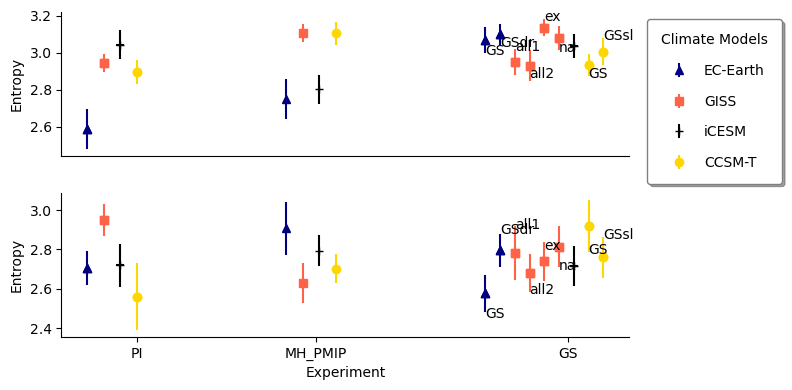

In [21]:
fig = plt.figure(figsize=(8, 4)) # Aumentei um pouco a largura para caber a legenda
ax = fig.add_subplot(2, 1, 1)
ay = fig.add_subplot(2, 1, 2)

# Dica: Vamos guardar os handles da legenda para não repetir nomes
handles, labels = [], []

# --- LOOP PI ---
for n in range(len(PI)):
    if modelPI[n] == 'GISS':
        color = 'tomato'
        fmt = 's'   # square
        mfc = color  # filled
        mec = color

    elif modelPI[n] == 'EC-Earth':
        color = 'navy'
        fmt = '^'   # triangle up
        mfc = color
        mec = color

    elif modelPI[n] == 'CCSM-T':
        color = 'gold'
        fmt = 'o'   # filled circle
        mfc = color
        mec = color

    elif modelPI[n] == 'iCESM':
        color = 'k'
        fmt = '+'  
        mfc = color
        mec = color
        
    x = 0.75 + n / len(PI)
    # ... (seu bloco de IF/ELSE para definir cores e marcadores permanece igual) ...
    
    # SST (Removido annotate)
    line = ax.errorbar(x, PI[n], yerr=PIstd[n], fmt=fmt, color=color, mfc=mfc, mec=mec, label=modelPI[n])
    ax.scatter(x, PI[n], color=color, marker=fmt)

    # PPT (Removido annotate)
    ay.errorbar(x, PIp[n], yerr=PIstdp[n], fmt=fmt, color=color, mfc=mfc, mec=mec)
    ay.scatter(x, PIp[n], color=color, marker=fmt)

# --- LOOP MH ---
for n in range(len(MH)):
    if modelPI[n]=='GISS':
        color = 'tomato'
        fmt = 's'   # square
        mfc = color  # filled
        mec = color
     
    elif modelPI[n]=='EC-Earth':
        color = 'navy'
        fmt = '^'   # triangle up
        mfc = color
        mec = color
    
    elif modelPI[n]=='CCSM-T':
        color = 'gold'
        fmt = 'o'   # filled circle
        mfc = color
        mec = color
        
    elif modelPI[n]=='iCESM':
        color = 'k'
        fmt = '+'  
        mfc = color
        mec = color
    x = 3.75 + n / len(MH)
    # ... (seu bloco de IF/ELSE igual) ...
    
    ax.errorbar(x, MH[n], yerr=PIstd[n], fmt=fmt, color=color, mfc=mfc, mec=mec)
    ay.errorbar(x, MHp[n], yerr=MHstdp[n], fmt=fmt, color=color, mfc=mfc, mec=mec)

# --- LOOP GS ---
for n in range(len(GS)):
    x=6.75+n*2/len(GS)
    if modelGS[n][:4]=='GISS':
        color = 'tomato'
        deslocp=GSstdp[n]
        desloc= GSstd[n]
        if modelGS[n][-1] =='2':
            desloc= -MHstd[n]
            deslocp= -GSstdp[n]
        elif modelGS[n][-1] =='1':
            deslocp=GSstdp[n]
        elif modelGS[n][-1] =='x':
            deslocp=GSstdp[n]-0.03
        elif modelGS[n][-1] =='a':
            deslocp=-GSstdp[n]
            desloc=-GSstd[n]
        fmt = 's'   # square
        mfc = color  # filled
        mec = color
        text= modelGS[n][4:]
        
    elif modelGS[n][:8]=='EC-Earth':
        color = 'navy'
        deslocp=-GSstdp[n]
        desloc= -GSstd[n]
        if modelGS[n][-1]=='r':
            deslocp=GSstdp[n]+0.01
        else:
            deslocp=-GSstdp[n]-0.02
        fmt = '^'   # triangle up
        mfc = color
        mec = color
        text= modelGS[n][8:]
            
    elif modelGS[n][:6]=='CCSM-T':
        color = 'gold'
        deslocp=GSstdp[n]
        desloc= GSstd[n]
        if len(modelGS[n])==8:
            deslocp=-GSstdp[n]
            desloc= -GSstd[n]
        fmt = 'o'   # filled circle
        mfc = color
        mec = color
        text= modelGS[n][6:]
        
    elif modelGS[n][:5]=='iCESM':
        color = 'k'
        deslocp=-GSstdp[n]+0.03
        desloc= GSstd[n]-0.02
        fmt = '+'  
        mfc = color
        mec = color
        text = ''
        
    # PLTO SST
    ax.annotate(text, (x, GS[n]+desloc-.01))
    ax.scatter(x, GS[n],color=color, marker=fmt, facecolors=mfc, edgecolors=mec)
    ax.errorbar(x, GS[n], yerr=GSstd[n], fmt=fmt, color=color, mfc=mfc, mec=mec)
    # PLOT PPT
    ay.annotate(text, (x, GSp[n]+deslocp-.01)) 
    ay.scatter(x, GSp[n] , color=color, marker=fmt, facecolors=mfc, edgecolors=mec)
    ay.errorbar(x, GSp[n], yerr=GSstdp[n], fmt=fmt, color=color, mfc=mfc, mec=mec)

# --- CONFIGURAÇÃO FINAL E LEGENDA ---
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))

# Styled Legend Box
ax.legend(by_label.values(), by_label.keys(), 
          title="Climate Models",          # Adds a title to the box
          loc='upper left', 
          bbox_to_anchor=(1.02, 1),        # Position: slightly right, top-aligned
          fancybox=True,                   # Rounded corners
          shadow=True,                     # Adds a subtle shadow for a 3D effect
          framealpha=1,                    # Opacity of the box background
          edgecolor='gray',                # Color of the box border
          borderpad=1,                     # Space inside the box
          labelspacing=1.2)                # Vertical space between entries

# Ensure the layout adjusts so the legend isn't cut off
plt.tight_layout(rect=[0, 0, 0.85, 1])     # Reserves 15% space on the right for the box


# Ajustes de eixos
x_pos = [1.5, 4.2, 8] # Ajuste conforme sua necessidade
my_xticks = ['PI', 'MH_PMIP', 'GS']
ay.set_xticks(x_pos)
ay.set_xticklabels(my_xticks)

ax.set_ylabel('Entropy')
ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)

ay.set_ylabel('Entropy')
ay.set_xlabel('Experiment')
ay.spines[['right', 'top']].set_visible(False)

plt.tight_layout() # Importante para a legenda não ser cortada
plt.show()

In [57]:
# Número de amostras e tamanho da amostra

B = 1000  # SIZE OF BOOTSTRAP SAMPLES
N = 1200  # MONTHS in EACH SAMPLE

limites = np.linspace(0.1, 1, num=20)#[0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]
model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CCSM-T','CCSM-T','CCSM-T','CCSM-T']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']


# Armazenar estatísticas de interesse
Entropys_bootstrap = np.zeros((len(model),B))
Entropyp_bootstrap = np.zeros((len(model),B))



In [58]:
for b in progressbar(range(B)):
    
    indices_amostra = np.random.choice(N, size=N, replace=True)
    
    Entropys_boot = np.zeros( (len(model),len(limites),len(limites),len(limites)) )
    #Entropyp_boot = np.zeros( (len(model),len(limites),len(limites),len(limites)) )

    P1_s = np.vstack(proj1_s)
    P2_s = np.vstack(proj2_s)
    P3_s = np.vstack(proj3_s)
   #P1_p = np.vstack(proj1_p)
   #P2_p = np.vstack(proj2_p)
   #P3_p = np.vstack(proj3_p)
    
    P1_s = P1_s[:,indices_amostra]
    P2_s = P2_s[:,indices_amostra]
    P3_s = P3_s[:,indices_amostra]
    #P1_p = P1_p[:,indices_amostra]
    #P2_p = P2_p[:,indices_amostra]
    #P3_p = P3_p[:,indices_amostra]
    
    P1s = [row for row in P1_s]
    P2s = [row for row in P2_s]
    P3s = [row for row in P3_s]
    #P1p = [row for row in P1_p]
    #P2p = [row for row in P2_p]
    #P3p = [row for row in P3_p]
    i=-1
    for limite1 in limites:
        i+=1
        j=-1
        for limite2 in limites:
            j+=1
            k=-1
            for limite3 in limites:
                k+=1
                # lista de limites contendo lista de modelos
                S = Entropia( clusteriza3d(P1s,P2s,P3s,limite1=limite1,limite2=limite2,limite=limite3) )
                #P = Entropia( clusteriza3d(P1p,P2p,P3p,limite1=limite1,limite2=limite2,limite=limite3) )
                Entropys_boot[:,i,j,k] = S
                #Entropyp_boot[:,i,j,k] = P
                
    Es = np.max(np.max(np.max(Entropys_boot,axis=1),axis=1),axis=1)
    #Ep = np.max(np.max(np.max(Entropyp_boot,axis=1),axis=1),axis=1)
    
    Entropys_bootstrap[:,b] = Es
    #Entropyp_bootstrap[:,b] = Ep
    
np.save('Entropys_bootstrap.npy',Entropys_bootstrap)
#np.save('Entropyp_bootstrap.npy',Entropyp_bootstrap)

[########### VAI CORINTHIANS! ###########] 1000/1000


In [61]:
# Calcula intervalo de confiança (percentil 2.5 e 97.5)
Entropyp_bootstrap = np.load('/home/iuri/xesmf/Entropyp_bootstrap.npy')
Entropys_bootstrap = np.load('/home/iuri/xesmf/Entropys_bootstrap.npy')

STDs,STDp = [],[]
for n,modelo in enumerate(model):
    intervalo_confianca_s = np.percentile(Entropys_bootstrap[n], [2.5, 97.5], axis=0)
    intervalo_confianca_p = np.percentile(Entropyp_bootstrap[n], [2.5, 97.5], axis=0)
    
    # Resultados
    STDs.append(-(intervalo_confianca_s[0]-intervalo_confianca_s[1]))
    STDp.append(-(intervalo_confianca_p[0]-intervalo_confianca_p[1]))
    print("Incerteza da média e intervalo de confiança para modelo ",modelo, cenario[n])
    print(f"precipitação-> [{round(intervalo_confianca_p[0]-intervalo_confianca_p[1],4),intervalo_confianca_p[0],intervalo_confianca_p[1]}]")##### 3D Thresholds
    print(f"SST-> [{round(intervalo_confianca_s[0]-intervalo_confianca_s[1],4),intervalo_confianca_s[0],intervalo_confianca_s[1]}]")##### 3D Thresholds

Incerteza da média e intervalo de confiança para modelo  EC-Earth PI
precipitação-> [(-0.0651, 2.961731706403333, 3.026831393393268)]
SST-> [(-0.0768, 2.8668468244396057, 2.9436347685049458)]
Incerteza da média e intervalo de confiança para modelo  EC-Earth MH
precipitação-> [(-0.0505, 3.062307315663496, 3.1128310103418735)]
SST-> [(-0.0446, 2.95672950735807, 3.0013599407005294)]
Incerteza da média e intervalo de confiança para modelo  EC-Earth GS
precipitação-> [(-0.068, 2.9162474454635268, 2.984280863263583)]
SST-> [(-0.0621, 3.0533045991039915, 3.1154300879077583)]
Incerteza da média e intervalo de confiança para modelo  EC-Earth GSdr
precipitação-> [(-0.0515, 3.132766898371245, 3.1842655492811804)]
SST-> [(-0.06, 2.9006018904206443, 2.960604661228639)]
Incerteza da média e intervalo de confiança para modelo  GISS GSALL1
precipitação-> [(-0.0666, 3.0532253965055047, 3.119833450546268)]
SST-> [(-0.0491, 3.1656174208333687, 3.2146972747137674)]
Incerteza da média e intervalo de confia

In [64]:
### ENTROPIAS COM INCERTEZA CALCULADA NO BOOTSTRAP DO LIMITE DO ENTROPY MAX
# VALORES PARA USAR NA TABELA DO ARTIGO

model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CCSM-T','CCSM-T','CCSM-T','CCSM-T']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']
Entropys_series=np.load('/home/iuri/xesmf/Entropys_series.npy')
Entropyp_series=np.load('/home/iuri/xesmf/Entropyp_series.npy')
limites = np.linspace(0.2, 0.9, num=40)#[0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95,1]

lista_sst = []
entropias=[]
#STDs=[]
print('Maximos da Entropys_series:')
max_s = 0
min_s = 10
for entropia,modelo,cen,STD in zip(Entropys_series,model,cenario,STDs):
    arg = np.unravel_index(np.argmax(entropia),entropia.shape)
    entropias.append(round(np.max(entropia),2))
    print(modelo,cen,'entropia:', round(np.max(entropia),2),'+/-',round(STD,2),'. thresholds:', round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3))
    maximo = np.max([round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3)])
    minimo = np.min([round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3)])
    if max_s < maximo:
        max_s = maximo
    if min_s > minimo:
        min_s = minimo
    
    # faz lista que guarda valor otimo para limites[arg[1]] e limites[arg[2]]
    lista_sst.append([arg[1],arg[2]])
    
print('menor threshod utilizado:',min_s,
      'maior threshold utilizado:',max_s)

print('\nMaximos da Entropyp_series:')
max_p = 0
min_p = 10
lista_ppt = []
entropiap=[]
#STDp=[]
for entropia,modelo,cen,STD in zip(Entropyp_series,model,cenario,STDp):
    arg = np.unravel_index(np.argmax(entropia),entropia.shape)
    entropiap.append(round(np.max(entropia),2))
    print(modelo,cen,'entropia:', round(np.max(entropia),2),'+/-',round(STD,2),'. thresholds:', round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3))
    maximo = np.max([round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3)])
    minimo = np.min([round(limites[arg[0]],3),round(limites[arg[1]],3),round(limites[arg[2]],3)])
    if max_p < maximo:
        max_p = maximo
    if min_p > minimo:
        min_p = minimo
    # faz lista que guarda valor otimo para limites[arg[1]] e limites[arg[2]]
    lista_ppt.append([arg[1],arg[2]])
    
print('menor threshod utilizado:',min_p,
      'maior threshold utilizado:',max_p)



Maximos da Entropys_series:
EC-Earth PI entropia: 2.92 +/- 0.08 . thresholds: 0.756 0.397 0.451
EC-Earth MH entropia: 2.98 +/- 0.04 . thresholds: 0.613 0.487 0.397
EC-Earth GS entropia: 3.09 +/- 0.06 . thresholds: 0.559 0.272 0.469
EC-Earth GSdr entropia: 2.94 +/- 0.06 . thresholds: 0.595 0.29 0.631
GISS GSALL1 entropia: 3.2 +/- 0.05 . thresholds: 0.415 0.487 0.415
GISS GSALL2 entropia: 3.1 +/- 0.06 . thresholds: 0.469 0.29 0.415
GISS GSEX entropia: 3.02 +/- 0.05 . thresholds: 0.631 0.523 0.685
GISS GSNA entropia: 3.19 +/- 0.04 . thresholds: 0.451 0.469 0.595
GISS MH entropia: 3.14 +/- 0.05 . thresholds: 0.326 0.433 0.487
GISS PI entropia: 3.06 +/- 0.06 . thresholds: 0.613 0.308 0.272
iCESM GS entropia: 3.17 +/- 0.05 . thresholds: 0.433 0.433 0.559
iCESM MH entropia: 3.15 +/- 0.06 . thresholds: 0.433 0.272 0.344
iCESM PI entropia: 2.98 +/- 0.06 . thresholds: 0.397 0.415 0.379
CCSM-T GS entropia: 3.05 +/- 0.06 . thresholds: 0.613 0.541 0.326
CCSM-T GSsl entropia: 3.01 +/- 0.07 . thresho

In [823]:
# Plot da series de Entropia para diferentes n_clusters para cada modelo
fig = plt.figure(figsize=(30,30))
start = 0 #usar apenas n_clusters
modelos=[0,2,4,6,8,9,10,11,12,13,14,15,16,17,18,19,20]

ys, yp = [], []

for m in range(len(lista_sst)):
    ys.append(Entropys_series[m,:,lista_sst[m][1],lista_sst[m][2]] )
    yp.append(Entropyp_series[m,:,lista_ppt[m][1],lista_ppt[m][2]] )
ncs = limites
ncp = limites

stds=[]
stdp=[]
count=0

for m in range(len(y)):
    stds.append(np.std(ys[m][start:]))
    stdp.append(np.std(yp[m][start:]))
    count+=1

<Figure size 3000x3000 with 0 Axes>

Text(0.5, 0.98, 'EC-Earth')

Text(0, 0.5, 'Entropy')

Text(0.5, 0, 'Threshold')

Text(0.5, 1.0, 'SST')

Text(0, 0.5, 'Entropy')

...

Text(0.5, 0, 'Threshold')

Text(0.5, 1.0, 'PPT')

Text(0, 0.5, 'Entropy')

Text(0.5, 0, 'Threshold')

Text(0.5, 1.0, 'PPT')

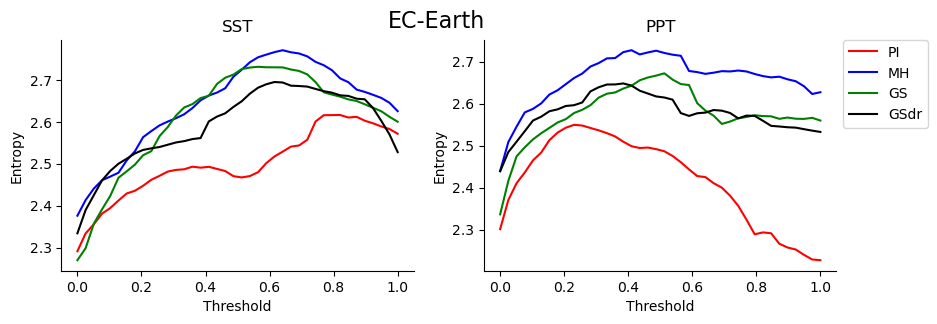

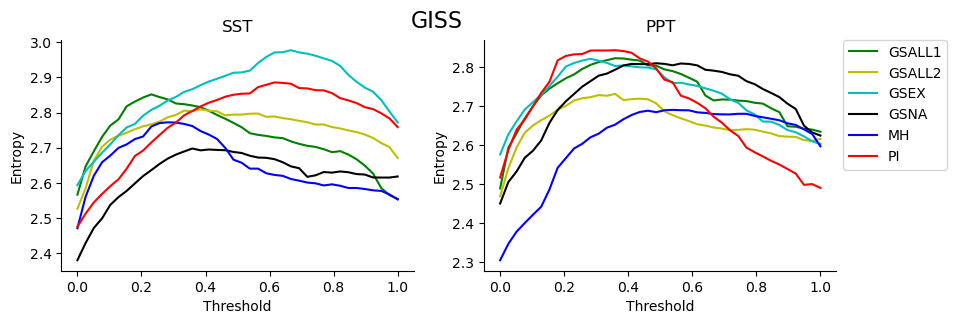

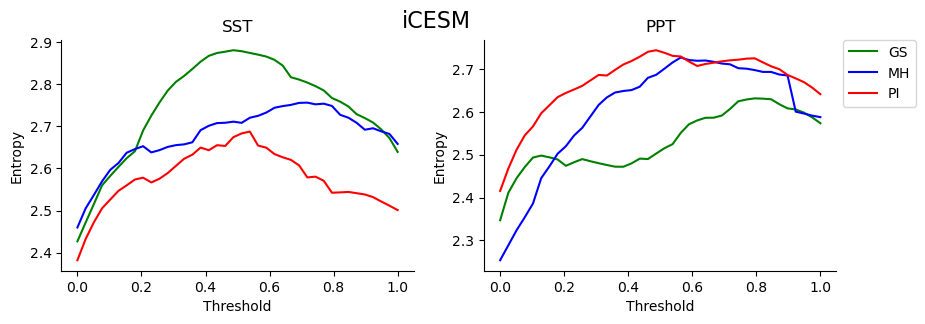

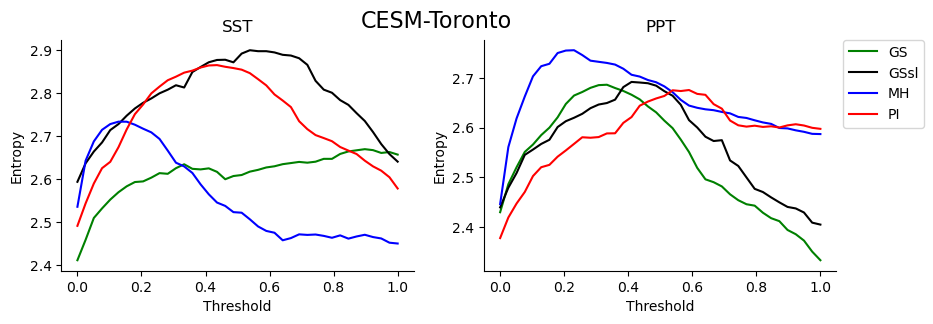

In [824]:
# THRESHOLD PLOTS, COM DUAS DIMENSOES DE TRESHOLD FIXAS NO VALOR OTIMO....

model=['EC-Earth','EC-Earth','EC-Earth','EC-Earth','GISS','GISS','GISS','GISS','GISS','GISS','iCESM','iCESM','iCESM','CCSM-T','CCSM-T','CCSM-T','CCSM-T']
cenario=['PI','MH','GS','GSdr','GSALL1','GSALL2','GSEX','GSNA','MH','PI','GS','MH','PI','GS','GSsl','MH','PI']

fig = plt.figure(figsize=(10,3))
fig.suptitle('EC-Earth', fontsize=16)

ax = fig.add_subplot(1, 2, 1)

m=-1
for cen in cenario[0:4]:
    m+=1
    if cen =='PI':
        plt.plot(ncs,ys[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncs,ys[m], color = 'b', label=cenario[m])
    elif cen =='GS':
        plt.plot(ncs,ys[m], color = 'g', label=cenario[m])
    elif cen =='GSdr':
        plt.plot(ncs,ys[m], color = 'k', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('SST')
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)


ax = fig.add_subplot(1, 2, 2)

m=-1
for cen in cenario[0:4]:
    m+=1
    if cen =='PI':
        plt.plot(ncp,yp[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncp,yp[m], color = 'b', label=cenario[m])
    elif cen =='GS':
        plt.plot(ncp,yp[m], color = 'g', label=cenario[m])
    elif cen =='GSdr':
        plt.plot(ncp,yp[m], color = 'k', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('PPT')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)

#GISS

fig = plt.figure(figsize=(10,3))
fig.suptitle('GISS', fontsize=16)

ax = fig.add_subplot(1, 2, 1)
m=3
for cen in cenario[4:10]:
    m+=1
    if cen =='PI':
        plt.plot(ncs,ys[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncs,ys[m], color = 'b', label=cenario[m])
    elif cen =='GSALL1':
        plt.plot(ncs,ys[m], color = 'g', label=cenario[m])
    elif cen =='GSALL2':
        plt.plot(ncs,ys[m], color = 'y', label=cenario[m])
    elif cen =='GSNA':
        plt.plot(ncs,ys[m], color = 'k', label=cenario[m])
    elif cen =='GSEX':
        plt.plot(ncs,ys[m], color = 'c', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('SST')
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)

ax = fig.add_subplot(1, 2, 2)
m=3
for cen in cenario[4:10]:
    m+=1
    if cen =='PI':
        plt.plot(ncp,yp[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncp,yp[m], color = 'b', label=cenario[m])
    elif cen =='GSALL1':
        plt.plot(ncp,yp[m], color = 'g', label=cenario[m])
    elif cen =='GSALL2':
        plt.plot(ncp,yp[m], color = 'y', label=cenario[m])
    elif cen =='GSNA':
        plt.plot(ncp,yp[m], color = 'k', label=cenario[m])
    elif cen =='GSEX':
        plt.plot(ncp,yp[m], color = 'c', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('PPT')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)

#iCESM

fig = plt.figure(figsize=(10,3))
fig.suptitle('iCESM', fontsize=16)

ax = fig.add_subplot(1, 2, 1)
m=9
for cen in cenario[10:13]:
    m+=1
    if cen =='PI':
        plt.plot(ncs,ys[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncs,ys[m], color = 'b', label=cenario[m])
    elif cen =='GS':
        plt.plot(ncs,ys[m], color = 'g', label=cenario[m])
    elif cen =='GSdr':
        plt.plot(ncs,ys[m], color = 'k', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('SST')
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)

ax = fig.add_subplot(1, 2, 2)
m=9
for cen in cenario[10:13]:
    m+=1
    if cen =='PI':
        plt.plot(ncp,yp[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncp,yp[m], color = 'b', label=cenario[m])
    elif cen =='GS':
        plt.plot(ncp,yp[m], color = 'g', label=cenario[m])
    elif cen =='GSdr':
        plt.plot(ncp,yp[m], color = 'k', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('PPT')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)


#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)


# TORONTO

fig = plt.figure(figsize=(10,3))
fig.suptitle('CESM-Toronto', fontsize=16)

ax = fig.add_subplot(1, 2, 1)
m=12
for cen in cenario[13:]:
    m+=1
    if cen =='PI':
        plt.plot(ncs,ys[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncs,ys[m], color = 'b', label=cenario[m])
    elif cen =='GS':
        plt.plot(ncs,ys[m], color = 'g', label=cenario[m])
    elif cen =='GSsl':
        plt.plot(ncs,ys[m], color = 'k', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('SST')
#plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)

ax = fig.add_subplot(1, 2, 2)
m=12
for cen in cenario[13:]:
    m+=1 
    if cen =='PI':
        plt.plot(ncp,yp[m], color = 'r', label=cenario[m])
    elif cen =='MH':
        plt.plot(ncp,yp[m], color = 'b', label=cenario[m])
    elif cen =='GS':
        plt.plot(ncp,yp[m], color = 'g', label=cenario[m])
    elif cen =='GSsl':
        plt.plot(ncp,yp[m], color = 'k', label=cenario[m])
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel('Entropy')
    ax.set_xlabel('Threshold')
    ax.set_title('PPT')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

#plt.axvline(x=0.2, ls='--',alpha=0.5)
#plt.axvline(x=0.75, ls='--',alpha=0.5)

In [65]:
# CHECK DO QUE ESTA EM CADA VETOR USADO NOS PLOTS...

for mod,cen,entropia,STD in zip(model,cenario,entropias,STDs):
    print(mod,cen,entropia,STD)
    
for mod,cen,entropia,STD in zip(model,cenario,entropiap,STDp):
    print(mod,cen,entropia,STD)

EC-Earth PI 2.92 0.07678794406534006
EC-Earth MH 2.98 0.04463043334245942
EC-Earth GS 3.09 0.06212548880376678
EC-Earth GSdr 2.94 0.060002770807994654
GISS GSALL1 3.2 0.049079853880398705
GISS GSALL2 3.1 0.05959186265355276
GISS GSEX 3.02 0.05400810591091032
GISS GSNA 3.19 0.0432010152998239
GISS MH 3.14 0.053677679504402054
GISS PI 3.06 0.056677649927900475
iCESM GS 3.17 0.04765182473639884
iCESM MH 3.15 0.06109195267678302
iCESM PI 2.98 0.060167964487221504
CCSM-T GS 3.05 0.06151620605353836
CCSM-T GSsl 3.01 0.06921080270536173
CCSM-T MH 3.09 0.058020156060255346
CCSM-T PI 3.11 0.051318171386442124
EC-Earth PI 3.0 0.06509968698993474
EC-Earth MH 3.09 0.050523694678377584
EC-Earth GS 2.96 0.06803341780005612
EC-Earth GSdr 3.17 0.05149865090993533
GISS GSALL1 3.1 0.06660805404076342
GISS GSALL2 3.04 0.05196220914735239
GISS GSEX 3.17 0.056106050241461425
GISS GSNA 3.12 0.053319455837020246
GISS MH 3.16 0.054150183939756236
GISS PI 3.15 0.049266533654880096
iCESM GS 2.92 0.0736707456982

Text(0.75, 2.84321205593466, 'EC-Earth')

<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

Text(0.75, 2.9349003130100653, 'EC-Earth')

Text(1.0, 3.1166776499279005, 'GISS')

...

([<matplotlib.axis.XTick at 0x7f6c4b7fdff0>,
 [Text(1.5, 0, 'PI'), Text(4.2, 0, 'MH'), Text(8.5, 0, 'GS')])

Text(0, 0.5, 'Entropy')

[]

Text(0, 0.5, 'Entropy')

Text(0.5, 0, 'Experiment')

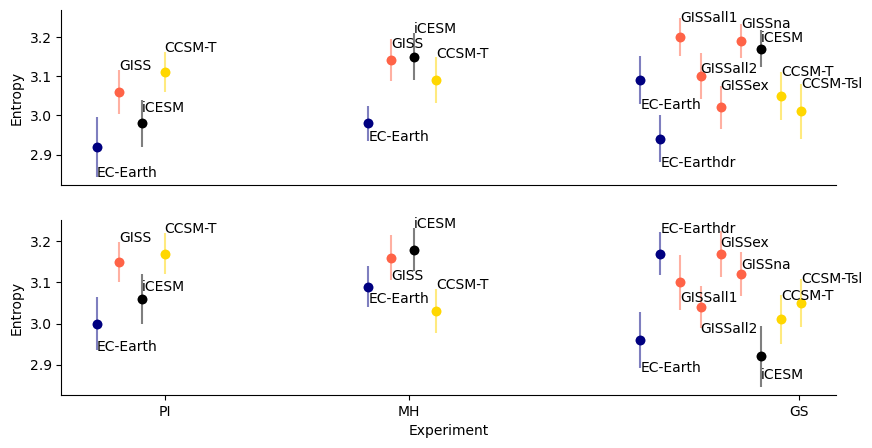

In [102]:
## SST

n=0 # contador
PI=[]
PIstd=[]
MH=[]
MHstd=[]
GS=[]
GSstd=[]

for cen in cenario:
    if cen == 'PI':
        PI.append(entropias[n])
        PIstd.append(STDs[n])
    elif cen == 'MH':
        MH.append(entropias[n])
        MHstd.append(STDs[n])
    else:
        GS.append(entropias[n])
        GSstd.append(STDs[n])
    n+=1
## Precipitation

n=0 # contador
PIp=[]
PIstdp=[]
MHp=[]
MHstdp=[]
GSp=[]
GSstdp=[]

for cen in cenario:
    if cen == 'PI':
        PIp.append(entropiap[n])
        PIstdp.append(STDp[n])
    elif cen == 'MH':
        MHp.append(entropiap[n])
        MHstdp.append(STDp[n])
    else:
        GSp.append(entropiap[n])
        GSstdp.append(STDp[n])
    n+=1

modelPI=['EC-Earth','GISS','iCESM','CCSM-T']
modelGS=['EC-Earth','EC-Earthdr','GISSall1','GISSall2','GISSex','GISSna','iCESM','CCSM-T','CCSM-Tsl']

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(2, 1, 1) #SST
ay = fig.add_subplot(2, 1, 2) # PPT
    
for n in range(len(PI)):
    x=0.75+n/(len(PI))
    
    if modelPI[n]=='GISS':
        color = 'tomato'
        deslocp=PIstdp[n]
        desloc= PIstd[n]
     
    elif modelPI[n]=='EC-Earth':
        color = 'navy'
        deslocp=-PIstdp[n]
        desloc= -PIstd[n]
    
    elif modelPI[n]=='CCSM-T':
        color = 'gold'
        deslocp=PIstdp[n]
        desloc= PIstd[n]
        
    elif modelPI[n]=='iCESM':
        color = 'k'
        deslocp=PIstdp[n]-0.04
        desloc= PIstd[n]-0.03
        
    # PlOT SST
    ax.annotate(modelPI[n], (x, PI[n]+desloc))
    ax.scatter(x, PI[n],color=color)
    ax.errorbar(x, PI[n], yerr=PIstd[n], fmt="o",alpha=0.5,color=color)
    # PLOT PPT
    ay.scatter(x, PIp[n],color=color)
    ay.errorbar(x, PIp[n], yerr=PIstdp[n], fmt="o",alpha=0.5,color=color)
    ay.annotate(modelPI[n], (x, PIp[n]+deslocp))
    
 
for n in range(len(MH)):
    x=3.75+n/len(MH)
    
    if modelPI[n]=='GISS':
        color = 'tomato'
        deslocp=-MHstdp[n]
        desloc= MHstd[n]-0.02
     
    elif modelPI[n]=='EC-Earth':
        color = 'navy'
        deslocp=-MHstdp[n]+0.01
        desloc= -MHstd[n]
    
    elif modelPI[n]=='CCSM-T':
        color = 'gold'
        deslocp=MHstdp[n]
        desloc= MHstd[n]
        
    elif modelPI[n]=='iCESM':
        color = 'k'
        deslocp=MHstdp[n]
        desloc= MHstd[n]
        
    # SST
    ax.annotate(modelPI[n], (x, MH[n]+desloc))
    ax.scatter(x, MH[n],color=color)
    ax.errorbar(x, MH[n], yerr=MHstd[n], fmt="o",alpha=0.5,color=color)
    
    ## PPT
    ay.annotate(modelPI[n], (x, MHp[n]+deslocp)) 
    ay.scatter(x, MHp[n],color=color)
    ay.errorbar(x, MHp[n], yerr=MHstdp[n], fmt="o",alpha=0.5,color=color)
       
    
for n in range(len(GS)):
    x=6.75+n*2/len(GS)
    if modelGS[n][:4]=='GISS':
        color = 'tomato'
        deslocp=GSstdp[n]
        desloc= GSstd[n]
        if modelGS[n][-1] =='2':
            desloc= MHstd[n]-0.04
            deslocp=-GSstdp[n]
        if modelGS[n][-1] =='1':
            deslocp=-GSstdp[n]+0.03
        elif modelGS[n][-1] =='x' or modelGS[n][-1] =='a':
            deslocp=GSstdp[n]-0.03
        
    elif modelGS[n][:8]=='EC-Earth':
        color = 'navy'
        deslocp=-GSstdp[n]
        desloc= -GSstd[n]
        if modelGS[n][-1]=='r':
            deslocp=GSstdp[n]+0.01
            
    elif modelGS[n][:6]=='CCSM-T':
        color = 'gold'
        deslocp=GSstdp[n]
        desloc= GSstd[n]
        
    elif modelGS[n][:5]=='iCESM':
        color = 'k'
        deslocp=-GSstdp[n]+0.03
        desloc= GSstd[n]-0.02
        
    # PLTO SST
    ax.annotate(modelGS[n], (x, GS[n]+desloc-.01))
    ax.scatter(x, GS[n],label=modelGS[n],color=color)
    ax.errorbar(x, GS[n], yerr=GSstd[n], fmt="o",alpha=0.5,color=color)
    # PLOT PPT
    ay.annotate(modelGS[n], (x, GSp[n]+deslocp-.01)) 
    ay.scatter(x, GSp[n],color=color)
    ay.errorbar(x, GSp[n], yerr=GSstdp[n], fmt="o",alpha=0.5,color=color)

x=[1.5,4.2,8.5]
my_xticks = ['PI','MH','GS']
plt.xticks(x, my_xticks)
ax.set_ylabel('Entropy')
ax.set_xticks([])
ax.spines[['right', 'top']].set_visible(False)
#ax.title.set_text('SST')
ay.set_ylabel('Entropy')
ay.set_xlabel('Experiment')
ay.spines[['right', 'top']].set_visible(False)
#ay.title.set_text('PPT')

    
plt.show()     

## System States
Needs the original sea surface temperature and precipitation vectors with lat and lon from simulations
Available upon reasonable request to the Corresponding Author (Iuri Gorenstein)

##### 27 SYSTEM STATES PLOT

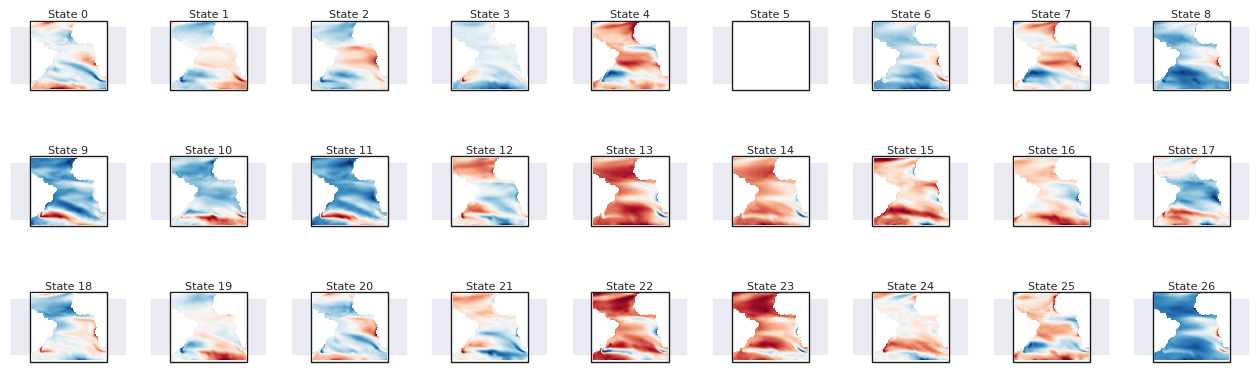

In [22]:
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
import os


### CMAP PARA CHUVA ############################
top = cm.get_cmap('Greens', 12)
bottom = cm.get_cmap('Oranges_r', 12)
newcolors = np.vstack((bottom(np.linspace(0, 1, 12)),
                       top(np.linspace(0, 1, 12))))
cmpchuva = ListedColormap(newcolors, name='OrangeGreen')
################################################

modos = ['sst']

for modo in modos:
    
    sns.set_theme(rc={'figure.figsize':(16,5)})
    fig, axes = plt.subplots(3, 9, subplot_kw={'projection': ccrs.PlateCarree()})
    
    if modo == 'sst':
        cmap = "RdBu_r"
        level = 0.4
        Patterns = Cluster_patterns_PCA
        
    elif modo == 'ppt':
        cmap=cmpchuva
        level = 0.4
        Patterns = Cluster_patternp_PCA

    levels = np.linspace(-level,level, 20)
    for c,ax in enumerate(axes.flatten()): # estados possiveis, sao 27

        ## PLOT #########################################
        #ax.set_extent([-65, 24, -49, 29.5], ccrs.PlateCarree())
        #im = ax.contourf(lon, lat, Patterns[c],levels=levels,cmap=cmap,extend='both',transform=ccrs.PlateCarree()) ## MUDAR PARA AZUL E VERMELHO TRADICIONAL cmap='bwr'         
        # 1. Desenha o Mapa
        pattern = Patterns[c]
        im = OffsetImage(pattern, zoom=0.6, cmap=cmap, origin='lower')
        ab = AnnotationBbox(im, (0, 0), frameon=True, pad=0.1)
        ax.add_artist(ab)
                
        #ax.coastlines(linewidths=1)
        #ax.add_feature(cf.BORDERS, linestyle=':', alpha=.5)
        ax.set_title('State ' + str(c), fontsize=8)
